# CS313 Final Notebook — Vietnam Biodiversity Forecasting Pipeline

**Goal:** build a complete, defensible pipeline for forecasting 2024 grid-level biodiversity richness in Vietnam.

This notebook is detailed and end-to-end, with the validation/EDA depth from the original `PIPELINE3.ipynb` upgraded to the 2009-2024 dataset:

1. **Pre-processing**: load and audit processed GBIF, Hansen forest, and Open-Meteo data.
2. **EDA**: inspect data coverage, biodiversity distribution, temporal/spatial patterns, and ecological covariates.
3. **Feature engineering + selection**: create lag/history features and enforce an honest forecast policy.
4. **Modelling**: train the final XGBoost forecast model on 2009-2023 and hold out 2024.
5. **Evaluation + ablation**: evaluate the final model and explain the feature-set decisions.
6. **Interpretation**: inspect feature importance and model limitations.

**Target:** `normalized_richness_01`, a 0-1 relative biodiversity richness index adjusted for observation effort. It is **not** an absolute number of species.

## 0. Setup

This cell locates the project root automatically, so the notebook can run from the repo root or from `notebook_worktree/datamining/`.

In [1]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.ensemble import ExtraTreesRegressor, HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import ElasticNet, LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GroupKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from xgboost import XGBRegressor

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 140)

for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / "notebook_worktree" / "datamining" / "processed").exists():
        PROJECT_ROOT = candidate
        break
else:
    raise FileNotFoundError("Cannot locate notebook_worktree/datamining/processed")

WORKTREE = PROJECT_ROOT / "notebook_worktree"
PROCESSED_DIR = WORKTREE / "datamining" / "processed"
REPORT_DIR = WORKTREE / "reports"
FIG_DIR = REPORT_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
TARGET = "normalized_richness_01"
TEST_YEAR = 2024

print("Project root:", PROJECT_ROOT)
print("Processed data:", PROCESSED_DIR)
print("Reports:", REPORT_DIR)
def save_figure(filename: str) -> None:
    """Save the current Matplotlib figure into the final report figure folder."""
    FIG_DIR.mkdir(parents=True, exist_ok=True)
    plt.savefig(FIG_DIR / filename, dpi=180, bbox_inches="tight")


Project root: /Users/longle/CS313/biodiversity
Processed data: /Users/longle/CS313/biodiversity/notebook_worktree/datamining/processed
Reports: /Users/longle/CS313/biodiversity/notebook_worktree/reports


## 1. Data Loading + Validation (2009-2024)

This section ports the deeper validation logic from the original `datamining/PIPELINE3.ipynb`, but runs it on the final 2009-2024 processed data.

Validation goals:

- confirm shape, schema, key uniqueness, and year coverage for GBIF, Hansen forest, and Open-Meteo;
- detect missingness, duplicate `(grid_id, year)` rows, invalid value ranges, constant/near-constant columns, and sparse grid histories;
- document exactly how the model-ready EDA table is merged;
- verify that `normalized_richness_01` is a bounded 0-1 target, not raw species count.


In [2]:
gbif_path = PROCESSED_DIR / "gbif_diversity_2009_2024.csv"
forest_path = PROCESSED_DIR / "forest_stats_2009_2024.csv"
weather_path = PROCESSED_DIR / "weather_yearly_2009_2024.csv"

GBIF = pd.read_csv(gbif_path)
FOREST = pd.read_csv(forest_path)
WEATHER = pd.read_csv(weather_path)

raw_datasets = {
    "GBIF biodiversity": GBIF,
    "Hansen forest": FOREST,
    "Open-Meteo weather": WEATHER,
}

health_rows = []
missing_rows = []
range_rows = []
constant_rows = []

for name, df in raw_datasets.items():
    key_duplicates = df.duplicated(subset=["grid_id", "year"]).sum() if {"grid_id", "year"}.issubset(df.columns) else np.nan
    health_rows.append(
        {
            "dataset": name,
            "rows": len(df),
            "columns": df.shape[1],
            "grid_cells": df["grid_id"].nunique() if "grid_id" in df.columns else np.nan,
            "year_min": int(df["year"].min()) if "year" in df.columns else np.nan,
            "year_max": int(df["year"].max()) if "year" in df.columns else np.nan,
            "duplicate_rows": int(df.duplicated().sum()),
            "duplicate_grid_year_keys": int(key_duplicates) if pd.notna(key_duplicates) else np.nan,
            "missing_cells": int(df.isna().sum().sum()),
            "missing_cell_rate": float(df.isna().sum().sum() / df.size),
        }
    )

    missing_pct = df.isna().mean().sort_values(ascending=False)
    for column, rate in missing_pct[missing_pct.gt(0)].head(12).items():
        missing_rows.append({"dataset": name, "column": column, "missing_rate": float(rate), "missing_count": int(df[column].isna().sum())})

    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    for column in numeric_cols:
        series = df[column].replace([np.inf, -np.inf], np.nan).dropna()
        if series.empty:
            continue
        range_rows.append(
            {
                "dataset": name,
                "column": column,
                "min": float(series.min()),
                "p01": float(series.quantile(0.01)),
                "median": float(series.median()),
                "mean": float(series.mean()),
                "p99": float(series.quantile(0.99)),
                "max": float(series.max()),
                "std": float(series.std()),
            }
        )
        std = float(series.std()) if len(series) > 1 else 0.0
        top_freq = float(series.value_counts(normalize=True, dropna=True).iloc[0]) if not series.empty else 1.0
        if std < 1e-9 or top_freq > 0.99:
            constant_rows.append(
                {
                    "dataset": name,
                    "column": column,
                    "std": std,
                    "top_value_frequency": top_freq,
                    "n_unique": int(series.nunique()),
                }
            )

data_health = pd.DataFrame(health_rows)
missing_report = pd.DataFrame(missing_rows)
range_report = pd.DataFrame(range_rows)
constant_report = pd.DataFrame(constant_rows)
if not constant_report.empty:
    constant_report = constant_report.sort_values(["dataset", "top_value_frequency"], ascending=[True, False])

value_checks = pd.DataFrame(
    [
        {
            "check": "GBIF target normalized_richness_01 in [0, 1]",
            "status": bool(GBIF[TARGET].between(0, 1).all()),
            "evidence": f"min={GBIF[TARGET].min():.4f}, max={GBIF[TARGET].max():.4f}",
        },
        {
            "check": "GBIF effort-adjusted formula matches n_species / log1p(n_observations)",
            "status": bool(np.nanmax(np.abs(GBIF["effort_adjusted_richness"] - GBIF["n_species"] / np.log1p(GBIF["n_observations"]))) < 1e-9),
            "evidence": "max absolute formula difference < 1e-9",
        },
        {
            "check": "Forest cover percentage in [0, 100]",
            "status": bool(FOREST["forest_cover_pct"].between(0, 100).all()),
            "evidence": f"min={FOREST['forest_cover_pct'].min():.2f}, max={FOREST['forest_cover_pct'].max():.2f}",
        },
        {
            "check": "Rainfall is non-negative where available",
            "status": bool(WEATHER["total_rainfall_mm"].ge(0).all()),
            "evidence": f"min={WEATHER['total_rainfall_mm'].min():.1f} mm",
        },
    ]
)

data_health.to_csv(REPORT_DIR / "final_data_validation_2009_2024.csv", index=False)
range_report.to_csv(REPORT_DIR / "final_numeric_range_report_2009_2024.csv", index=False)
constant_report.to_csv(REPORT_DIR / "final_constant_feature_report_2009_2024.csv", index=False)

print("Source tables loaded from processed 2009-2024 files:")
display(data_health)
print("Top missing columns by source table:")
display(missing_report if not missing_report.empty else pd.DataFrame({"message": ["No missing values in source tables"]}))
print("Value-range sanity checks:")
display(value_checks)
print("Constant / near-constant numeric columns:")
display(constant_report.head(20) if not constant_report.empty else pd.DataFrame({"message": ["No near-constant numeric columns detected"]}))


Source tables loaded from processed 2009-2024 files:


,dataset,rows,columns,grid_cells,year_min,year_max,duplicate_rows,duplicate_grid_year_keys,missing_cells,missing_cell_rate
0,GBIF biodiversity,9245,16,2569,2009,2024,0,0,0,0.0
1,Hansen forest,246352,5,15397,2009,2024,0,0,0,0.0
2,Open-Meteo weather,87850,7,9777,2009,2024,0,0,0,0.0


Top missing columns by source table:


,message
0,No missing values in source tables


Value-range sanity checks:


,check,status,evidence
0,"GBIF target normalized_richness_01 in [0, 1]",True,"min=0.0087, max=1.0000"
1,GBIF effort-adjusted formula matches n_species...,True,max absolute formula difference < 1e-9
2,"Forest cover percentage in [0, 100]",True,"min=0.00, max=96.71"
3,Rainfall is non-negative where available,True,min=461.0 mm


Constant / near-constant numeric columns:


,message
0,No near-constant numeric columns detected


### 1.1 Spatiotemporal continuity and merge health

The original notebook checked 2019-2024 continuity. Here the expected panel is expanded to **2009-2024**. GBIF is naturally sparse because it only contains grid-years with biodiversity observations; forest/weather are environmental covariate tables and can be much denser.


In [3]:
EXPECTED_YEARS = list(range(2009, TEST_YEAR + 1))
EXPECTED_YEAR_COUNT = len(EXPECTED_YEARS)

continuity_rows = []
yearly_coverage_rows = []

for name, df in raw_datasets.items():
    if not {"grid_id", "year"}.issubset(df.columns):
        continue
    grid_year_counts = df.groupby("grid_id")["year"].nunique()
    expected_rows = df["grid_id"].nunique() * EXPECTED_YEAR_COUNT
    continuity_rows.append(
        {
            "dataset": name,
            "unique_grids": int(df["grid_id"].nunique()),
            "rows": int(len(df)),
            "expected_full_panel_rows": int(expected_rows),
            "panel_coverage_rate": float(len(df) / expected_rows) if expected_rows else np.nan,
            "complete_16_year_grids": int(grid_year_counts.eq(EXPECTED_YEAR_COUNT).sum()),
            "complete_grid_rate": float(grid_year_counts.eq(EXPECTED_YEAR_COUNT).mean()),
            "mean_years_per_grid": float(grid_year_counts.mean()),
            "median_years_per_grid": float(grid_year_counts.median()),
            "min_years_per_grid": int(grid_year_counts.min()),
            "max_years_per_grid": int(grid_year_counts.max()),
        }
    )
    by_year = df.groupby("year").agg(rows=("grid_id", "size"), grids=("grid_id", "nunique")).reset_index()
    for row in by_year.itertuples(index=False):
        yearly_coverage_rows.append({"dataset": name, "year": int(row.year), "rows": int(row.rows), "grids": int(row.grids)})

continuity_report = pd.DataFrame(continuity_rows)
yearly_coverage = pd.DataFrame(yearly_coverage_rows)
yearly_grid_pivot = yearly_coverage.pivot_table(index="year", columns="dataset", values="grids", aggfunc="first").reset_index()

forest_coverage = len(GBIF[["grid_id", "year"]].merge(FOREST[["grid_id", "year"]], on=["grid_id", "year"], how="inner")) / len(GBIF)
weather_coverage = len(GBIF[["grid_id", "year"]].merge(WEATHER[["grid_id", "year"]], on=["grid_id", "year"], how="inner")) / len(GBIF)

env_inner = FOREST.merge(WEATHER, on=["grid_id", "year"], how="inner")
final_inner = GBIF.merge(FOREST, on=["grid_id", "year"], how="inner").merge(WEATHER, on=["grid_id", "year"], how="inner")
eda_df = GBIF.merge(FOREST, on=["grid_id", "year"], how="left").merge(WEATHER, on=["grid_id", "year"], how="left")

merge_health = pd.DataFrame(
    [
        {"stage": "GBIF only", "rows": len(GBIF), "unique_grids": GBIF["grid_id"].nunique(), "year_min": GBIF["year"].min(), "year_max": GBIF["year"].max(), "note": "Observed biodiversity labels"},
        {"stage": "Forest coverage over GBIF", "rows": int(round(forest_coverage * len(GBIF))), "unique_grids": np.nan, "year_min": 2009, "year_max": 2024, "note": f"{forest_coverage:.1%} of GBIF grid-years have forest features"},
        {"stage": "Weather coverage over GBIF", "rows": int(round(weather_coverage * len(GBIF))), "unique_grids": np.nan, "year_min": 2009, "year_max": 2024, "note": f"{weather_coverage:.1%} of GBIF grid-years have weather features"},
        {"stage": "Forest ∩ Weather", "rows": len(env_inner), "unique_grids": env_inner["grid_id"].nunique(), "year_min": env_inner["year"].min(), "year_max": env_inner["year"].max(), "note": "Environmental grid-years available before joining labels"},
        {"stage": "GBIF ∩ Forest ∩ Weather", "rows": len(final_inner), "unique_grids": final_inner["grid_id"].nunique(), "year_min": final_inner["year"].min(), "year_max": final_inner["year"].max(), "note": "Rows if all three sources are required"},
        {"stage": "EDA left-join table", "rows": len(eda_df), "unique_grids": eda_df["grid_id"].nunique(), "year_min": eda_df["year"].min(), "year_max": eda_df["year"].max(), "note": "Keeps all GBIF labels; missing weather remains explicit"},
    ]
)

continuity_report.to_csv(REPORT_DIR / "final_continuity_2009_2024.csv", index=False)
yearly_grid_pivot.to_csv(REPORT_DIR / "final_yearly_grid_coverage_2009_2024.csv", index=False)
merge_health.to_csv(REPORT_DIR / "final_merge_health_2009_2024.csv", index=False)

display(continuity_report)
display(yearly_grid_pivot.tail(16))
display(merge_health)
print("EDA left-join table shape:", eda_df.shape)


,dataset,unique_grids,rows,expected_full_panel_rows,panel_coverage_rate,complete_16_year_grids,complete_grid_rate,mean_years_per_grid,median_years_per_grid,min_years_per_grid,max_years_per_grid
0,GBIF biodiversity,2569,9245,41104,0.224917,41,0.015960,3.598677,2.0,1,16
1,Hansen forest,15397,246352,246352,1.000000,15397,1.000000,16.000000,16.0,16,16
2,Open-Meteo weather,9777,87850,156432,0.561586,50,0.005114,8.985374,9.0,3,16


dataset,year,GBIF biodiversity,Hansen forest,Open-Meteo weather
0,2009,296,15397,9777
1,2010,324,15397,9777
2,2011,387,15397,9777
3,2012,382,15397,238
4,2013,431,15397,266
5,2014,450,15397,286
6,2015,445,15397,288
7,2016,490,15397,324
8,2017,542,15397,341
9,2018,785,15397,491


,stage,rows,unique_grids,year_min,year_max,note
0,GBIF only,9245,2569.0,2009,2024,Observed biodiversity labels
1,Forest coverage over GBIF,9245,NaN,2009,2024,100.0% of GBIF grid-years have forest features
2,Weather coverage over GBIF,5887,NaN,2009,2024,63.7% of GBIF grid-years have weather features
3,Forest ∩ Weather,87850,9777.0,2009,2024,Environmental grid-years available before join...
4,GBIF ∩ Forest ∩ Weather,5887,1500.0,2009,2024,Rows if all three sources are required
5,EDA left-join table,9245,2569.0,2009,2024,Keeps all GBIF labels; missing weather remains...


EDA left-join table shape: (9245, 24)


## 2. EDA - Exploratory Data Analysis

This section mirrors the stronger EDA from `PIPELINE3.ipynb`, updated for 2009-2024 and the final 0-1 target.

EDA questions:

1. What does the target distribution look like after effort correction and p99 scaling?
2. How sparse is GBIF over time and space?
3. Which environmental/features are skewed, noisy, missing, or strongly correlated?
4. Which observations justify later preprocessing decisions such as leakage removal, lag/history features, robust scaling for linear models, and weather exclusion?


,feature,non_null,missing_rate,mean,median,std,skew,p01,p99
2,n_observations,9245,0.000000,70.279827,4.000000,504.968735,27.627873,1.000000,1278.600000
3,n_species,9245,0.000000,17.158031,3.000000,38.459665,4.805570,1.000000,189.000000
1,effort_adjusted_richness,9245,0.000000,4.391002,2.164043,5.679937,3.307364,0.558111,28.018188
6,forest_loss_pct_change,9245,0.000000,-0.566083,-0.144337,0.993750,-3.242988,-4.824873,-0.000000
5,forest_loss_ha,9245,0.000000,55.151827,15.099547,95.261236,3.239293,0.000000,458.492003
0,normalized_richness_01,9245,0.000000,0.159921,0.080429,0.192897,2.548005,0.020743,1.000000
10,n_hot_days,5887,0.363223,16.914897,3.000000,24.243639,1.550329,0.000000,93.140000
7,avg_temp,5887,0.363223,25.133300,26.200000,2.788407,-1.374526,16.500000,28.290000
8,total_rainfall_mm,5887,0.363223,2157.200662,2105.200000,642.482120,0.798834,870.962000,4162.860000
4,forest_cover_pct,9245,0.000000,31.012886,21.510000,28.493370,0.629593,0.000000,92.053600


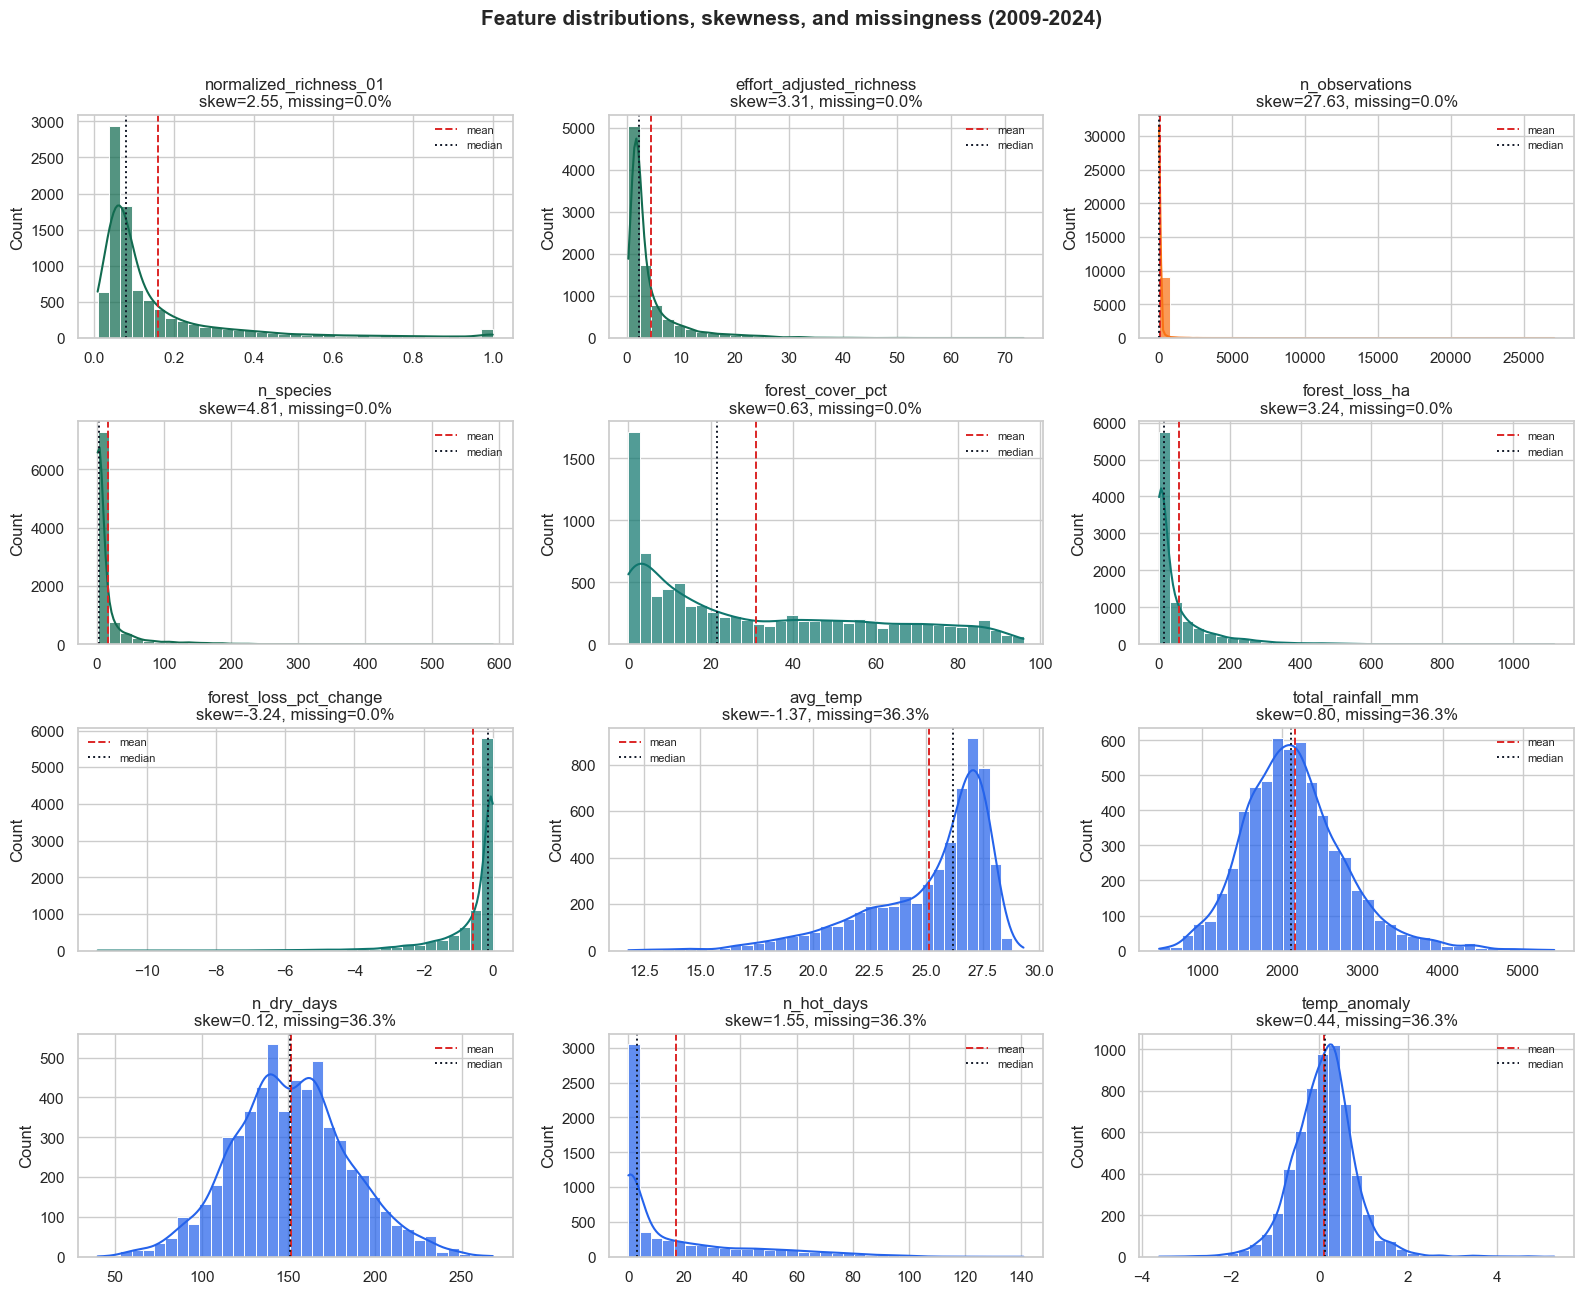

In [4]:
key_eda_features = [
    TARGET,
    "effort_adjusted_richness",
    "n_observations",
    "n_species",
    "forest_cover_pct",
    "forest_loss_ha",
    "forest_loss_pct_change",
    "avg_temp",
    "total_rainfall_mm",
    "n_dry_days",
    "n_hot_days",
    "temp_anomaly",
]
key_eda_features = [column for column in key_eda_features if column in eda_df.columns]

distribution_rows = []
for column in key_eda_features:
    series = eda_df[column].replace([np.inf, -np.inf], np.nan).dropna()
    distribution_rows.append(
        {
            "feature": column,
            "non_null": int(series.count()),
            "missing_rate": float(1 - series.count() / len(eda_df)),
            "mean": float(series.mean()),
            "median": float(series.median()),
            "std": float(series.std()),
            "skew": float(series.skew()),
            "p01": float(series.quantile(0.01)),
            "p99": float(series.quantile(0.99)),
        }
    )
distribution_stats = pd.DataFrame(distribution_rows).sort_values("skew", key=lambda s: s.abs(), ascending=False)
distribution_stats.to_csv(REPORT_DIR / "final_feature_distribution_stats_2009_2024.csv", index=False)
display(distribution_stats)

n_cols = 3
n_rows = int(np.ceil(len(key_eda_features) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 3.2 * n_rows))
axes = np.atleast_1d(axes).flatten()
palette = {
    "biodiversity": "#126b50",
    "effort": "#f97316",
    "forest": "#0f766e",
    "weather": "#2563eb",
}

for idx, column in enumerate(key_eda_features):
    ax = axes[idx]
    series = eda_df[column].replace([np.inf, -np.inf], np.nan).dropna()
    if column in {TARGET, "effort_adjusted_richness", "n_species"}:
        color = palette["biodiversity"]
    elif column == "n_observations":
        color = palette["effort"]
    elif "forest" in column:
        color = palette["forest"]
    else:
        color = palette["weather"]
    sns.histplot(series, bins=35, kde=True, color=color, alpha=0.72, ax=ax)
    ax.axvline(series.mean(), color="#dc2626", linestyle="--", linewidth=1.4, label="mean")
    ax.axvline(series.median(), color="#111827", linestyle=":", linewidth=1.4, label="median")
    ax.set_title(f"{column}\nskew={series.skew():.2f}, missing={1 - series.count()/len(eda_df):.1%}")
    ax.set_xlabel("")
    ax.legend(frameon=False, fontsize=8)
for idx in range(len(key_eda_features), len(axes)):
    axes[idx].axis("off")
fig.suptitle("Feature distributions, skewness, and missingness (2009-2024)", fontsize=15, fontweight="semibold", y=1.01)
plt.tight_layout()
save_figure("final_pipeline_feature_distributions_2009_2024.png")
plt.show()


,year,grid_years,unique_grids,total_observations,total_species_cell_count,mean_species,mean_observations,mean_effort_adjusted,median_effort_adjusted,mean_target,median_target,target_std,weather_coverage
0,2009,296,296,8501,4292,14.500000,28.719595,4.103556,1.864005,0.150265,0.069277,0.182079,0.641892
1,2010,324,324,13197,5211,16.083333,40.731481,4.133535,1.759512,0.150490,0.065394,0.211734,0.604938
2,2011,387,387,12718,4675,12.080103,32.863049,3.504458,1.820478,0.128588,0.067660,0.171207,0.578811
3,2012,382,382,18470,4741,12.410995,48.350785,3.521759,1.820478,0.128728,0.067660,0.171899,0.623037
4,2013,431,431,15221,5776,13.401392,35.315545,3.826911,1.820478,0.141206,0.067660,0.170617,0.617169
5,2014,450,450,16661,6190,13.755556,37.024444,3.849076,1.820478,0.140956,0.067660,0.177933,0.635556
6,2015,445,445,20867,6617,14.869663,46.892135,4.038562,1.820478,0.148959,0.067660,0.181775,0.647191
7,2016,490,490,37350,8460,17.265306,76.224490,4.340884,2.164043,0.157316,0.080429,0.188551,0.661224
8,2017,542,542,28028,7666,14.143911,51.712177,3.892331,1.820478,0.144209,0.067660,0.166380,0.629151
9,2018,785,785,52312,11894,15.151592,66.639490,3.887209,1.820478,0.141501,0.067660,0.180188,0.625478


,quantity,meaning,min,median,p99,max
0,effort_adjusted_richness,n_species / log1p(n_observations),0.235377,2.164043,28.018188,73.506538
1,normalized_richness_01,p99-capped effort-adjusted richness scaled to ...,0.008748,0.080429,1.000000,1.000000


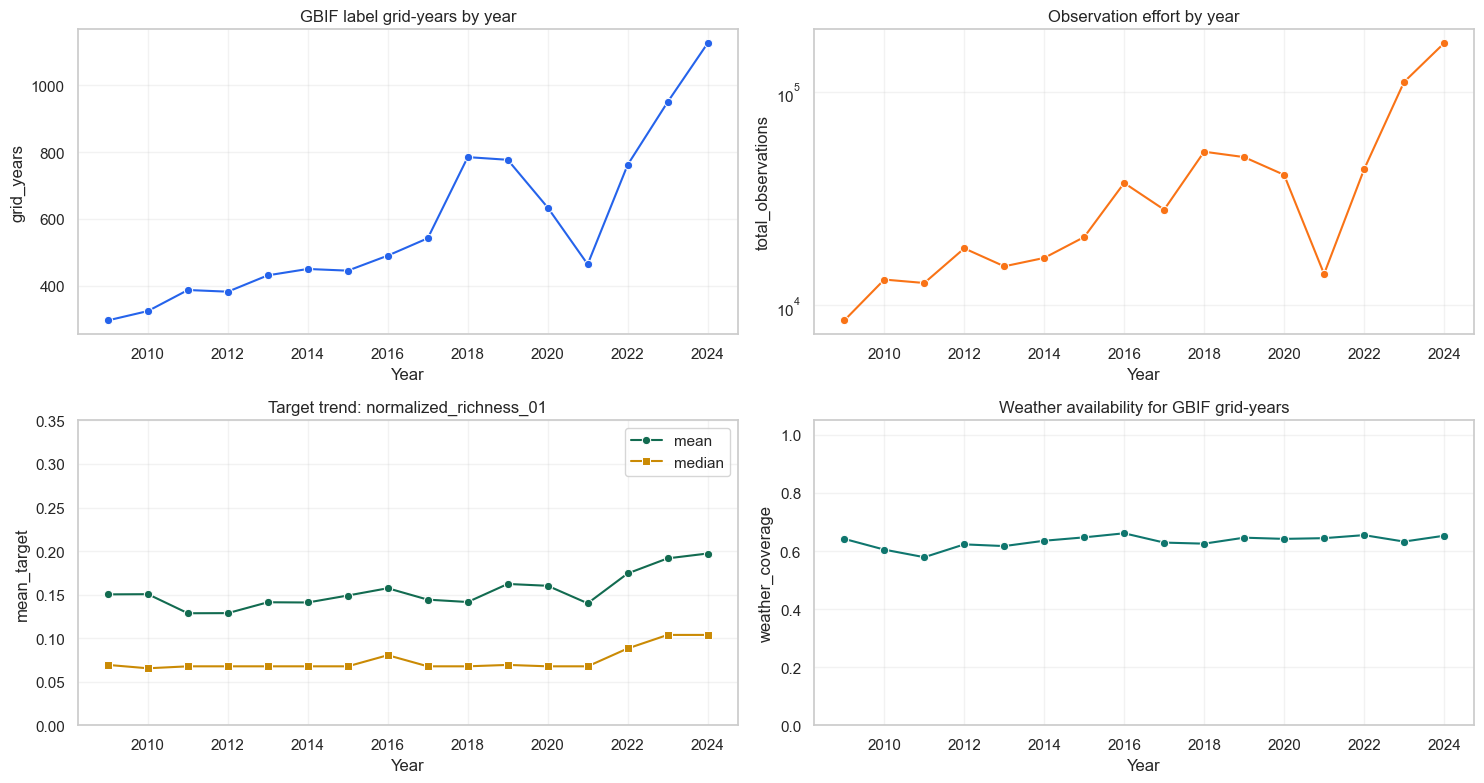

In [5]:
target_yearly = (
    eda_df.groupby("year")
    .agg(
        grid_years=("grid_id", "count"),
        unique_grids=("grid_id", "nunique"),
        total_observations=("n_observations", "sum"),
        total_species_cell_count=("n_species", "sum"),
        mean_species=("n_species", "mean"),
        mean_observations=("n_observations", "mean"),
        mean_effort_adjusted=("effort_adjusted_richness", "mean"),
        median_effort_adjusted=("effort_adjusted_richness", "median"),
        mean_target=(TARGET, "mean"),
        median_target=(TARGET, "median"),
        target_std=(TARGET, "std"),
        weather_coverage=("avg_temp", lambda s: s.notna().mean()),
    )
    .reset_index()
)
target_yearly.to_csv(REPORT_DIR / "final_target_yearly_eda_2009_2024.csv", index=False)
display(target_yearly)

target_scale = pd.DataFrame(
    [
        {"quantity": "effort_adjusted_richness", "meaning": "n_species / log1p(n_observations)", "min": GBIF["effort_adjusted_richness"].min(), "median": GBIF["effort_adjusted_richness"].median(), "p99": GBIF["effort_adjusted_richness"].quantile(0.99), "max": GBIF["effort_adjusted_richness"].max()},
        {"quantity": TARGET, "meaning": "p99-capped effort-adjusted richness scaled to [0, 1]", "min": GBIF[TARGET].min(), "median": GBIF[TARGET].median(), "p99": GBIF[TARGET].quantile(0.99), "max": GBIF[TARGET].max()},
    ]
)
display(target_scale)

fig, axes = plt.subplots(2, 2, figsize=(15, 8))
sns.lineplot(data=target_yearly, x="year", y="grid_years", marker="o", ax=axes[0, 0], color="#2563eb")
axes[0, 0].set_title("GBIF label grid-years by year")
sns.lineplot(data=target_yearly, x="year", y="total_observations", marker="o", ax=axes[0, 1], color="#f97316")
axes[0, 1].set_title("Observation effort by year")
axes[0, 1].set_yscale("log")
sns.lineplot(data=target_yearly, x="year", y="mean_target", marker="o", label="mean", ax=axes[1, 0], color="#126b50")
sns.lineplot(data=target_yearly, x="year", y="median_target", marker="s", label="median", ax=axes[1, 0], color="#ca8a04")
axes[1, 0].set_title("Target trend: normalized_richness_01")
axes[1, 0].set_ylim(0, max(0.35, target_yearly["mean_target"].max() * 1.2))
sns.lineplot(data=target_yearly, x="year", y="weather_coverage", marker="o", ax=axes[1, 1], color="#0f766e")
axes[1, 1].set_title("Weather availability for GBIF grid-years")
axes[1, 1].set_ylim(0, 1.05)
for ax in axes.flatten():
    ax.set_xlabel("Year")
    ax.grid(alpha=0.25)
plt.tight_layout()
save_figure("final_pipeline_temporal_eda_2009_2024.png")
plt.show()


Loaded Vietnam province boundaries: 63 provinces


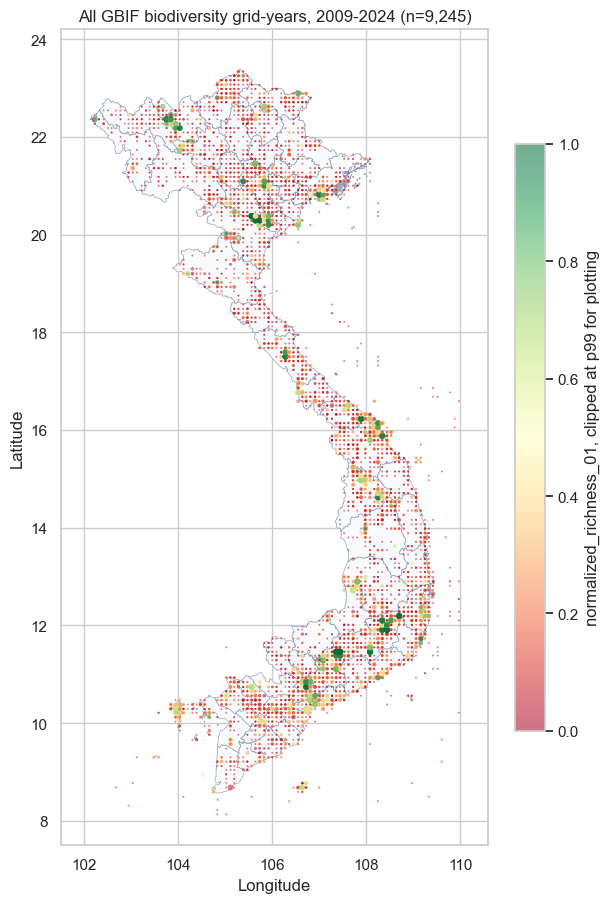

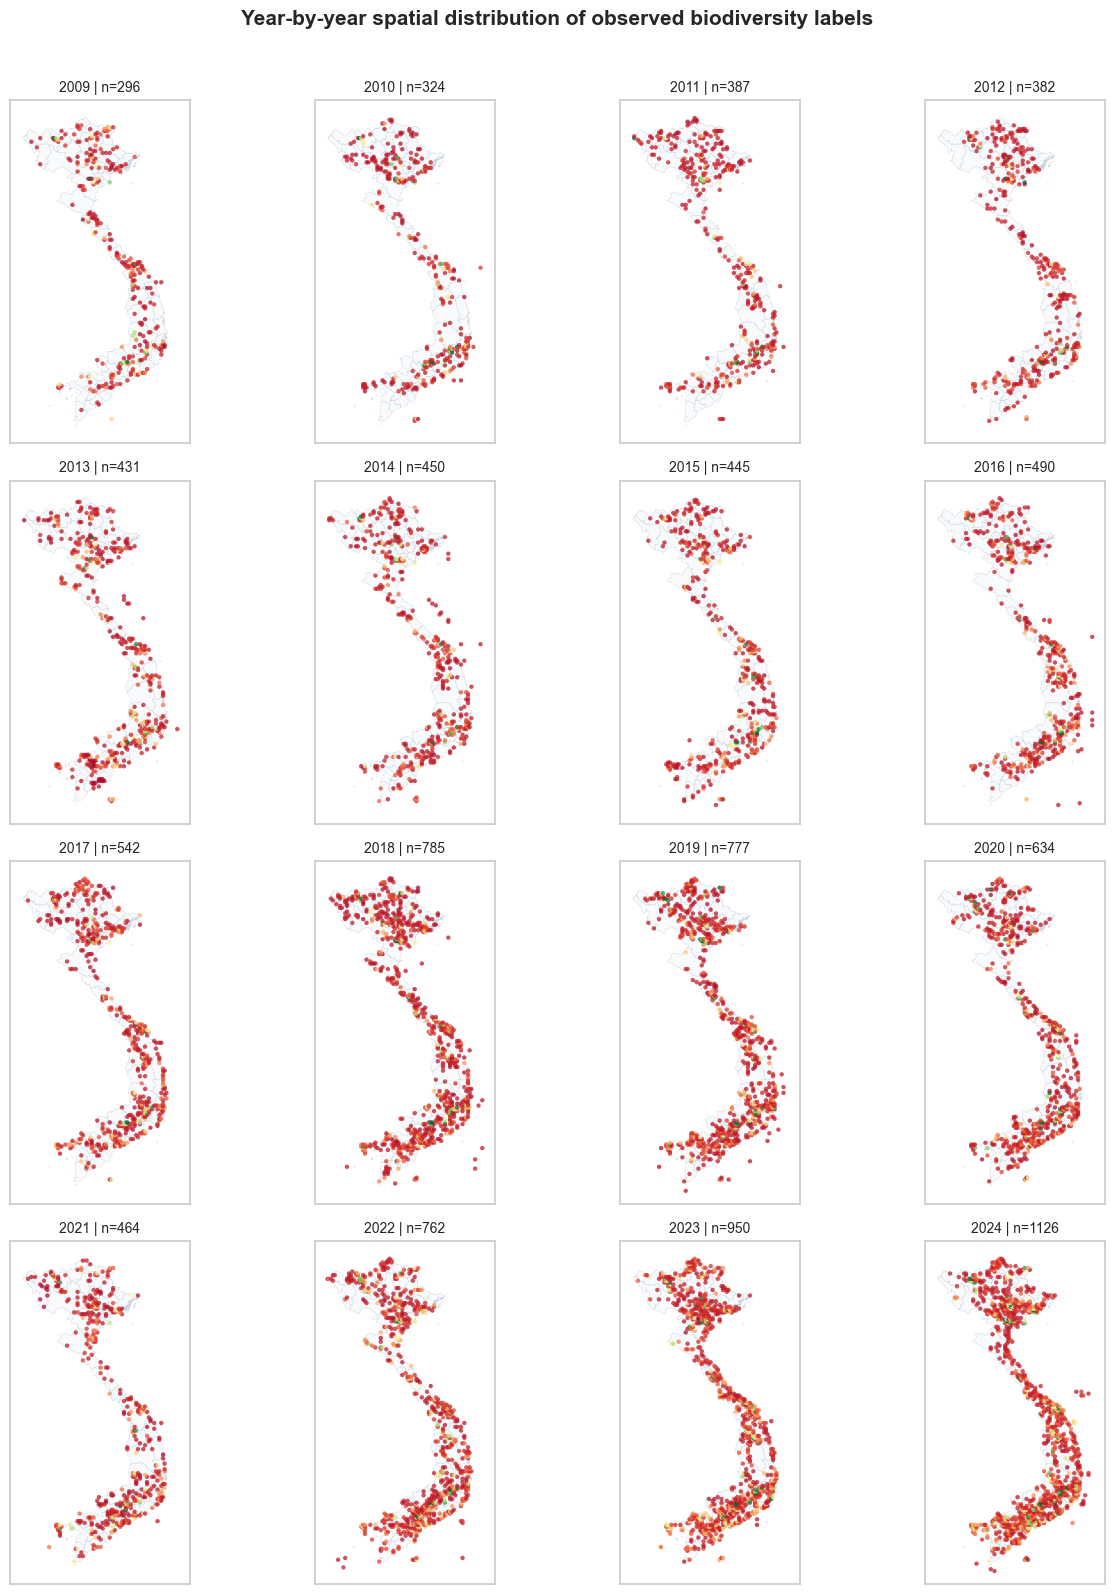

In [6]:
map_df = GBIF.dropna(subset=["lat", "lon", TARGET]).copy()
map_df["target_for_plot"] = map_df[TARGET].clip(upper=map_df[TARGET].quantile(0.99))
gpkg_path = WORKTREE / "datamining" / "dataset-2" / "gadm41_VNM.gpkg"
provinces = None
if gpkg_path.exists():
    try:
        import geopandas as gpd
        provinces = gpd.read_file(gpkg_path, layer="ADM_ADM_1")
        print(f"Loaded Vietnam province boundaries: {len(provinces)} provinces")
    except Exception as exc:
        print("Province boundary load failed; falling back to scatter-only maps:", exc)

fig, ax = plt.subplots(figsize=(6.2, 9.2))
if provinces is not None:
    provinces.plot(ax=ax, color="#f8fafc", edgecolor="#94a3b8", linewidth=0.45, zorder=1)
scatter = ax.scatter(
    map_df["lon"],
    map_df["lat"],
    c=map_df["target_for_plot"],
    s=np.clip(np.sqrt(map_df["n_observations"]), 2, 18),
    cmap="RdYlGn",
    vmin=0,
    vmax=map_df["target_for_plot"].max(),
    alpha=0.55,
    linewidths=0,
    zorder=2,
)
ax.set_xlim(101.5, 110.6)
ax.set_ylim(7.5, 24.2)
ax.set_title(f"All GBIF biodiversity grid-years, 2009-2024 (n={len(map_df):,})")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
cbar = plt.colorbar(scatter, ax=ax, shrink=0.72)
cbar.set_label("normalized_richness_01, clipped at p99 for plotting")
plt.tight_layout()
save_figure("final_pipeline_combined_spatial_eda_2009_2024.png")
plt.show()

years = sorted(map_df["year"].unique())
fig, axes = plt.subplots(4, 4, figsize=(13.2, 16.0), sharex=True, sharey=True)
axes = axes.flatten()
for idx, year in enumerate(years):
    ax = axes[idx]
    year_df = map_df[map_df["year"].eq(year)]
    if provinces is not None:
        provinces.plot(ax=ax, color="#f8fafc", edgecolor="#cbd5e1", linewidth=0.25, zorder=1)
    ax.scatter(
        year_df["lon"],
        year_df["lat"],
        c=year_df["target_for_plot"],
        s=10,
        cmap="RdYlGn",
        vmin=0,
        vmax=map_df["target_for_plot"].max(),
        alpha=0.75,
        linewidths=0,
        zorder=2,
    )
    ax.set_title(f"{int(year)} | n={len(year_df)}", fontsize=10)
    ax.set_xlim(101.5, 110.6)
    ax.set_ylim(7.5, 24.2)
    ax.set_xticks([])
    ax.set_yticks([])
for idx in range(len(years), len(axes)):
    axes[idx].axis("off")
fig.suptitle("Year-by-year spatial distribution of observed biodiversity labels", fontsize=15, fontweight="semibold", y=0.995)
plt.tight_layout(rect=[0, 0, 1, 0.985])
save_figure("final_pipeline_spatial_facets_2009_2024.png")
plt.show()


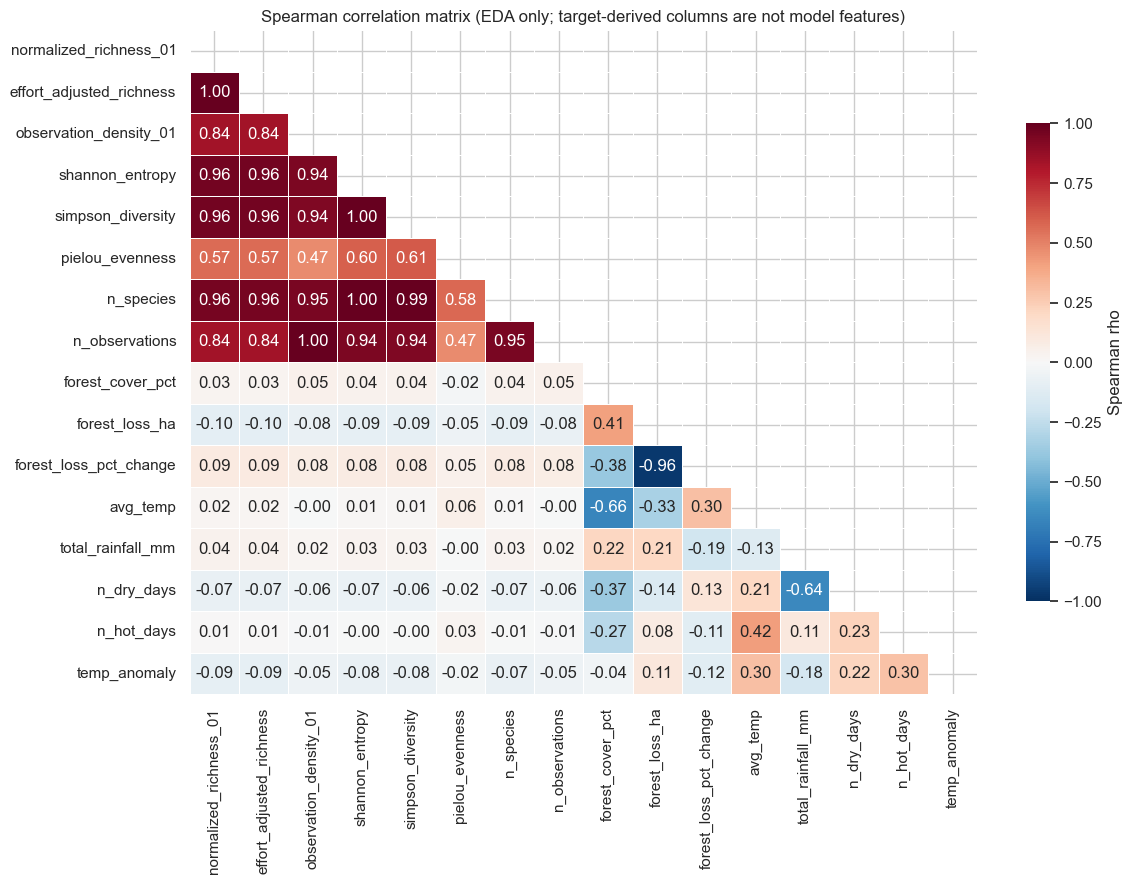

,feature,spearman_rho_with_target
0,effort_adjusted_richness,0.999875
1,shannon_entropy,0.964218
2,simpson_diversity,0.963612
3,n_species,0.957696
4,observation_density_01,0.842830
5,n_observations,0.842829
6,pielou_evenness,0.568317
7,forest_loss_ha,-0.096358
8,temp_anomaly,-0.093354
9,forest_loss_pct_change,0.089103


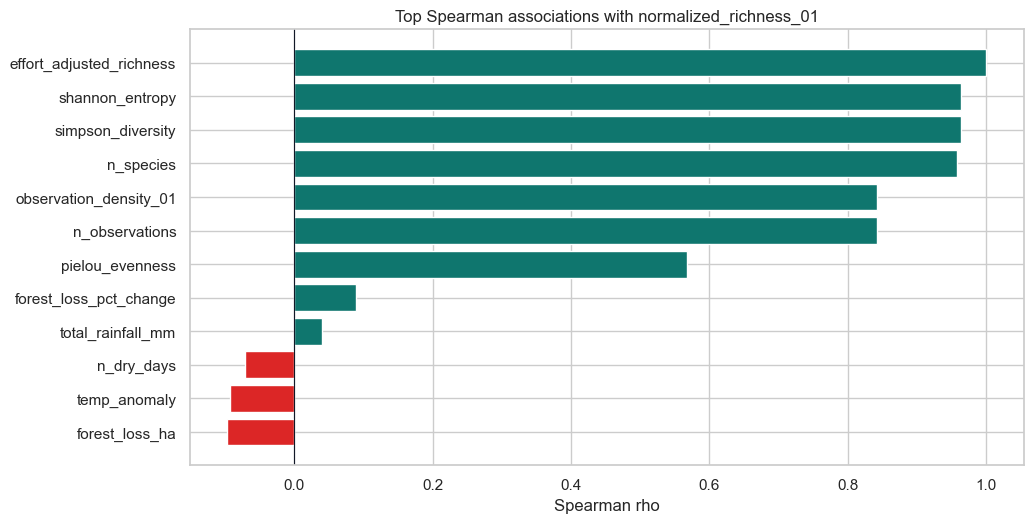

High-correlation feature pairs (|rho| > 0.90): 14


,feature_a,feature_b,spearman_rho
6,observation_density_01,n_observations,0.999999
7,shannon_entropy,simpson_diversity,0.998881
8,shannon_entropy,n_species,0.997898
10,simpson_diversity,n_species,0.994724
0,effort_adjusted_richness,shannon_entropy,0.964611
1,effort_adjusted_richness,simpson_diversity,0.964010
13,forest_loss_ha,forest_loss_pct_change,-0.960959
2,effort_adjusted_richness,n_species,0.958129
12,n_species,n_observations,0.952914
5,observation_density_01,n_species,0.952914


In [7]:
corr_cols = [
    TARGET,
    "effort_adjusted_richness",
    "observation_density_01",
    "shannon_entropy",
    "simpson_diversity",
    "pielou_evenness",
    "n_species",
    "n_observations",
    "forest_cover_pct",
    "forest_loss_ha",
    "forest_loss_pct_change",
    "avg_temp",
    "total_rainfall_mm",
    "n_dry_days",
    "n_hot_days",
    "temp_anomaly",
]
corr_cols = [column for column in corr_cols if column in eda_df.columns]
corr_matrix_spearman = eda_df[corr_cols].corr(method="spearman", numeric_only=True)

mask = np.triu(np.ones_like(corr_matrix_spearman, dtype=bool))
plt.figure(figsize=(12, 9))
sns.heatmap(
    corr_matrix_spearman,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    cbar_kws={"shrink": 0.72, "label": "Spearman rho"},
)
plt.title("Spearman correlation matrix (EDA only; target-derived columns are not model features)")
plt.tight_layout()
save_figure("final_pipeline_spearman_corr_2009_2024.png")
plt.show()

target_corr = (
    corr_matrix_spearman[TARGET]
    .drop(index=TARGET)
    .dropna()
    .sort_values(key=lambda s: s.abs(), ascending=False)
    .rename("spearman_rho_with_target")
    .reset_index()
    .rename(columns={"index": "feature"})
)
display(target_corr.head(15))

plt.figure(figsize=(10.5, 5.4))
plot_corr = target_corr.head(12).sort_values("spearman_rho_with_target")
colors = ["#dc2626" if value < 0 else "#0f766e" for value in plot_corr["spearman_rho_with_target"]]
plt.barh(plot_corr["feature"], plot_corr["spearman_rho_with_target"], color=colors)
plt.axvline(0, color="#111827", linewidth=0.8)
plt.title("Top Spearman associations with normalized_richness_01")
plt.xlabel("Spearman rho")
plt.tight_layout()
save_figure("final_pipeline_target_correlations_2009_2024.png")
plt.show()

feature_corr_cols = [column for column in corr_cols if column != TARGET]
feature_corr = eda_df[feature_corr_cols].corr(method="spearman", numeric_only=True)
high_corr_pairs = []
for i, feature_a in enumerate(feature_corr.columns):
    for feature_b in feature_corr.columns[i + 1:]:
        rho = feature_corr.loc[feature_a, feature_b]
        if pd.notna(rho) and abs(rho) > 0.9:
            high_corr_pairs.append({"feature_a": feature_a, "feature_b": feature_b, "spearman_rho": float(rho)})
multicollinearity_report = pd.DataFrame(high_corr_pairs).sort_values("spearman_rho", key=lambda s: s.abs(), ascending=False) if high_corr_pairs else pd.DataFrame(columns=["feature_a", "feature_b", "spearman_rho"])
multicollinearity_report.to_csv(REPORT_DIR / "final_multicollinearity_pairs_2009_2024.csv", index=False)
print(f"High-correlation feature pairs (|rho| > 0.90): {len(multicollinearity_report)}")
display(multicollinearity_report.head(20))


,feature,q1,q3,iqr,lower_bound,upper_bound,outlier_count,outlier_rate
1,n_observations,1.000000,19.000000,18.000000,-26.000000,46.000000,1345,0.145484
2,n_species,1.000000,13.000000,12.000000,-17.000000,31.000000,1293,0.139859
0,effort_adjusted_richness,1.442695,4.678455,3.235760,-3.410945,9.532095,1079,0.116712
5,forest_loss_pct_change,-0.668987,-0.007175,0.661812,-1.661706,0.985543,964,0.104273
4,forest_loss_ha,1.168843,65.603620,64.434777,-95.483324,162.255786,951,0.102866
9,n_hot_days,0.000000,27.000000,27.000000,-40.500000,67.500000,348,0.059113
10,temp_anomaly,-0.310000,0.490000,0.800000,-1.510000,1.690000,185,0.031425
6,avg_temp,23.655000,27.160000,3.505000,18.397500,32.417500,181,0.030746
7,total_rainfall_mm,1726.750000,2502.000000,775.250000,563.875000,3664.875000,158,0.026839
8,n_dry_days,129.000000,172.000000,43.000000,64.500000,236.500000,75,0.012740


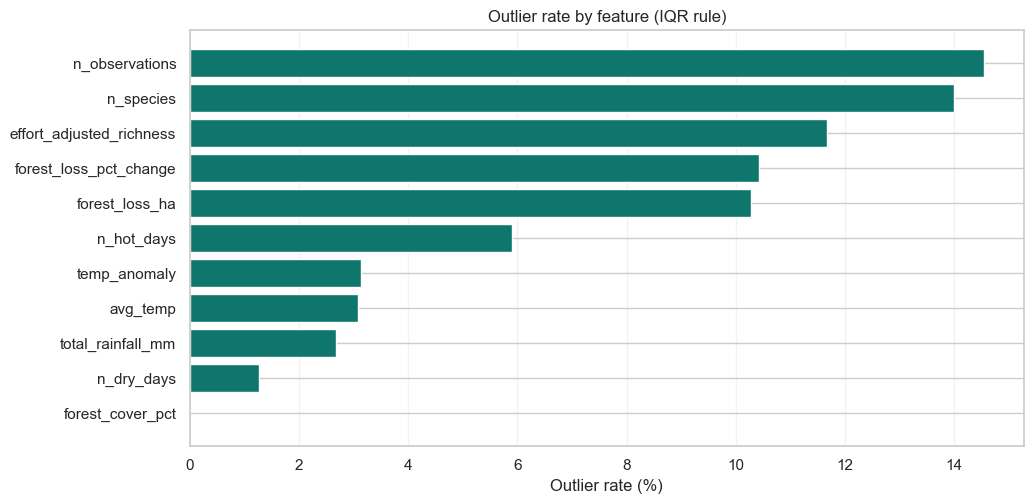

In [8]:
outlier_rows = []
for column in [c for c in key_eda_features if c not in {TARGET}]:
    series = eda_df[column].replace([np.inf, -np.inf], np.nan).dropna()
    if series.empty:
        continue
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outliers = series.lt(lower) | series.gt(upper)
    outlier_rows.append(
        {
            "feature": column,
            "q1": float(q1),
            "q3": float(q3),
            "iqr": float(iqr),
            "lower_bound": float(lower),
            "upper_bound": float(upper),
            "outlier_count": int(outliers.sum()),
            "outlier_rate": float(outliers.mean()),
        }
    )
outlier_report = pd.DataFrame(outlier_rows).sort_values("outlier_rate", ascending=False)
outlier_report.to_csv(REPORT_DIR / "final_outlier_iqr_2009_2024.csv", index=False)
display(outlier_report)

fig, ax = plt.subplots(figsize=(10.5, 5.2))
plot_outliers = outlier_report.sort_values("outlier_rate", ascending=True)
ax.barh(plot_outliers["feature"], plot_outliers["outlier_rate"] * 100, color="#0f766e")
ax.set_title("Outlier rate by feature (IQR rule)")
ax.set_xlabel("Outlier rate (%)")
ax.grid(axis="x", alpha=0.25)
plt.tight_layout()
save_figure("final_pipeline_outlier_rates_2009_2024.png")
plt.show()


## 3. Feature Engineering

The model is framed as **spatiotemporal forecasting**. For a grid in 2024, we allow:

- location (`lat`, `lon`) and calendar year;
- current forest state/loss (`forest_cover_pct`, `forest_loss_ha`, `forest_loss_pct_change`);
- **past** biodiversity and effort signals (`*_lag1`, `*_last_obs`, `*_hist_mean`, `*_hist_max`).

We explicitly exclude current-year `n_species`, current-year `n_observations`, and direct diversity derivatives to avoid leakage.

In [9]:
TARGETS_AND_DERIVED = {
    TARGET,
    "simpson_diversity",
    "pielou_evenness",
    "observation_density_01",
    "effort_adjusted_richness",
    "shannon_entropy",
    "hill_q0",
    "hill_q1",
    "hill_q2",
}
DROP_FORECAST = {
    "grid_id",
    "n_weighted_individuals",
    "n_species",
    "n_observations",
    *TARGETS_AND_DERIVED,
}
HISTORY_COLUMNS = [
    TARGET,
    "n_observations",
    "n_species",
    "forest_cover_pct",
    "forest_loss_ha",
    "forest_loss_pct_change",
]
WEATHER_HISTORY_COLUMNS = ["avg_temp", "total_rainfall_mm", "n_dry_days", "n_hot_days", "temp_anomaly"]


def add_lag_features(df: pd.DataFrame, columns: list[str]) -> pd.DataFrame:
    available = [column for column in columns if column in df.columns]
    lag = df[["grid_id", "year", *available]].copy()
    lag["year"] += 1
    lag = lag.rename(columns={column: f"{column}_lag1" for column in available})
    out = df.merge(lag, on=["grid_id", "year"], how="left")
    for column in [column for column in out.columns if column.endswith("_lag1")]:
        out[column] = out[column].fillna(out[column].median())
    return out


def add_history_features(df: pd.DataFrame, columns: list[str]) -> pd.DataFrame:
    out = df.sort_values(["grid_id", "year"]).copy()
    grouped = out.groupby("grid_id", group_keys=False)
    available = [column for column in columns if column in out.columns]
    for column in available:
        out[f"{column}_last_obs"] = grouped[column].shift(1)
        out[f"{column}_hist_mean"] = grouped[column].apply(lambda s: s.shift(1).expanding().mean()).reset_index(level=0, drop=True)
        out[f"{column}_hist_max"] = grouped[column].apply(lambda s: s.shift(1).expanding().max()).reset_index(level=0, drop=True)
    out["prev_year_seen"] = grouped["year"].shift(1)
    out["years_since_seen"] = (out["year"] - out["prev_year_seen"]).fillna(99)
    out["prior_records_for_cell"] = grouped.cumcount()
    out["log_prior_records_for_cell"] = np.log1p(out["prior_records_for_cell"])
    return out.drop(columns=["prev_year_seen"])


def add_spatial_temporal_features(df: pd.DataFrame, include_xy_features: bool, include_year_features: bool) -> pd.DataFrame:
    out = df.copy()
    if include_xy_features:
        out["lat2"] = out["lat"] ** 2
        out["lon2"] = out["lon"] ** 2
        out["lat_lon"] = out["lat"] * out["lon"]
        out["northness"] = np.clip((out["lat"] - 8.0) / (24.0 - 8.0), 0, 1)
        out["coast_west_gradient"] = np.clip((out["lon"] - 102.0) / (110.0 - 102.0), 0, 1)
    if include_year_features:
        out["year_centered"] = out["year"] - int(out["year"].min())
        out["year2"] = out["year_centered"] ** 2
    return out


def build_modeling_frame(include_weather: bool, include_xy_features: bool, include_year_features: bool) -> pd.DataFrame:
    df = GBIF.copy()
    if include_weather:
        df = df.merge(WEATHER, on=["grid_id", "year"], how="left")
    df = df.merge(FOREST, on=["grid_id", "year"], how="left")
    history_columns = HISTORY_COLUMNS + (WEATHER_HISTORY_COLUMNS if include_weather else [])
    df = add_lag_features(df, history_columns)
    df = add_history_features(df, history_columns)
    df = add_spatial_temporal_features(df, include_xy_features, include_year_features)
    return df.sort_values(["grid_id", "year"]).reset_index(drop=True)


def select_forecast_features(df: pd.DataFrame) -> list[str]:
    return [
        column
        for column in df.select_dtypes(include=[np.number]).columns
        if column not in DROP_FORECAST
    ]

In [10]:
final_frame = build_modeling_frame(
    include_weather=False,
    include_xy_features=False,
    include_year_features=False,
)
feature_cols = select_forecast_features(final_frame)

train = final_frame[final_frame["year"] < TEST_YEAR].copy()
test = final_frame[final_frame["year"] == TEST_YEAR].copy()
medians = train[feature_cols].median().fillna(0)
x_train = train[feature_cols].fillna(medians)
y_train = train[TARGET]
x_test = test[feature_cols].fillna(medians)
y_test = test[TARGET]

feature_audit = pd.DataFrame({"feature": feature_cols})
print(f"Rows: train={len(train):,}, test_2024={len(test):,}")
print(f"Final feature count: {len(feature_cols)}")
print("Forbidden current-year columns in features:", sorted(set(feature_cols) & {"n_species", "n_observations", TARGET}))
display(feature_audit.head(20))

Rows: train=8,119, test_2024=1,126
Final feature count: 33
Forbidden current-year columns in features: []


,feature
0,lat
1,lon
2,year
3,forest_cover_pct
4,forest_loss_ha
5,forest_loss_pct_change
6,normalized_richness_01_lag1
7,n_observations_lag1
8,n_species_lag1
9,forest_cover_pct_lag1


### 3.1 Preprocessing Audit

The old `PIPELINE3.ipynb` had explicit preprocessing cells for lag features, spatial context, leakage removal, scaling, and outlier handling. The final pipeline keeps the same intent, but updates the policy:

- target is already scaled to `[0, 1]`, so final evaluation stays on the interpretable target scale;
- current-year `n_species`, `n_observations`, and target-derived diversity columns are removed from features;
- lag/history features are computed only from previous rows within the same `grid_id`;
- missing lag/history values are imputed using train medians only;
- tree models do not need scaling, while linear baselines receive `RobustScaler` inside their sklearn pipelines.


In [11]:
def classify_feature_block(feature: str) -> str:
    if feature in {"year", "lat", "lon"}:
        return "base spatial/temporal"
    if feature.endswith("_lag1"):
        return "previous-year lag"
    if any(token in feature for token in ["_hist_", "_last_obs", "prior_records", "years_since_seen"]):
        return "historical grid-cell summary"
    if feature.startswith("forest_"):
        return "current forest context"
    if feature in WEATHER_HISTORY_COLUMNS or any(weather_token in feature for weather_token in ["temp", "rainfall", "dry_days", "hot_days"]):
        return "weather context"
    return "other numeric"

feature_preprocessing_audit = pd.DataFrame(
    {
        "feature": feature_cols,
        "feature_block": [classify_feature_block(feature) for feature in feature_cols],
        "missing_rate_before_imputation_train": [float(train[feature].isna().mean()) for feature in feature_cols],
        "train_median_imputation_value": [float(medians[feature]) for feature in feature_cols],
        "used_by_final_model": True,
    }
).sort_values(["feature_block", "feature"])

split_audit = pd.DataFrame(
    [
        {"split": "tuning_train", "years": "2009-2022", "rows": int((final_frame["year"] < 2023).sum()), "purpose": "hyperparameter fitting"},
        {"split": "validation", "years": "2023", "rows": int((final_frame["year"] == 2023).sum()), "purpose": "hyperparameter/model-family selection"},
        {"split": "final_train", "years": "2009-2023", "rows": int((final_frame["year"] < TEST_YEAR).sum()), "purpose": "final refit"},
        {"split": "test", "years": "2024", "rows": int((final_frame["year"] == TEST_YEAR).sum()), "purpose": "untouched final temporal holdout"},
    ]
)

forbidden_current_year = sorted(set(feature_cols) & {"n_species", "n_observations", TARGET, "effort_adjusted_richness", "shannon_entropy", "simpson_diversity", "pielou_evenness"})
leakage_audit = pd.DataFrame(
    [
        {"rule": "No current-year n_species", "status": "PASS" if "n_species" not in feature_cols else "FAIL"},
        {"rule": "No current-year n_observations", "status": "PASS" if "n_observations" not in feature_cols else "FAIL"},
        {"rule": "No direct target/derived diversity columns", "status": "PASS" if not forbidden_current_year else "FAIL", "evidence": ", ".join(forbidden_current_year) if forbidden_current_year else "none"},
        {"rule": "Lag/history features use previous grid-year records", "status": "PASS", "evidence": "implemented by year+1 self-join and groupby shift(1)/expanding over grid_id"},
    ]
)

feature_block_summary = (
    feature_preprocessing_audit.groupby("feature_block")
    .agg(n_features=("feature", "count"), mean_missing_train=("missing_rate_before_imputation_train", "mean"), max_missing_train=("missing_rate_before_imputation_train", "max"))
    .reset_index()
    .sort_values("n_features", ascending=False)
)

feature_preprocessing_audit.to_csv(REPORT_DIR / "final_feature_preprocessing_audit_2009_2024.csv", index=False)

display(split_audit)
display(leakage_audit)
display(feature_block_summary)
display(feature_preprocessing_audit.head(40))


,split,years,rows,purpose
0,tuning_train,2009-2022,7169,hyperparameter fitting
1,validation,2023,950,hyperparameter/model-family selection
2,final_train,2009-2023,8119,final refit
3,test,2024,1126,untouched final temporal holdout


,rule,status,evidence
0,No current-year n_species,PASS,NaN
1,No current-year n_observations,PASS,NaN
2,No direct target/derived diversity columns,PASS,none
3,Lag/history features use previous grid-year re...,PASS,implemented by year+1 self-join and groupby sh...


,feature_block,n_features,mean_missing_train,max_missing_train
2,historical grid-cell summary,21,0.255591,0.298189
3,previous-year lag,6,0.000000,0.000000
0,base spatial/temporal,3,0.000000,0.000000
1,current forest context,3,0.000000,0.000000


,feature,feature_block,missing_rate_before_imputation_train,train_median_imputation_value,used_by_final_model
0,lat,base spatial/temporal,0.000000,15.340000,True
1,lon,base spatial/temporal,0.000000,106.640000,True
2,year,base spatial/temporal,0.000000,2018.000000,True
3,forest_cover_pct,current forest context,0.000000,22.770000,True
4,forest_loss_ha,current forest context,0.000000,14.760552,True
5,forest_loss_pct_change,current forest context,0.000000,-0.139010,True
23,forest_cover_pct_hist_max,historical grid-cell summary,0.298189,23.620000,True
22,forest_cover_pct_hist_mean,historical grid-cell summary,0.298189,23.315000,True
21,forest_cover_pct_last_obs,historical grid-cell summary,0.298189,23.115000,True
26,forest_loss_ha_hist_max,historical grid-cell summary,0.298189,23.075787,True


### 3.2 Final Feature Multicollinearity Matrix

This audit uses the **actual final model feature set** (`feature_cols`) after train-only median imputation. It intentionally excludes the target, current-year `n_species`, current-year `n_observations`, and target-derived diversity columns.

The heatmap shows Spearman rank correlation among predictors. The VIF table is added as a defense aid: tree ensembles can tolerate correlated predictors, but this table makes redundant feature families transparent for the final report.


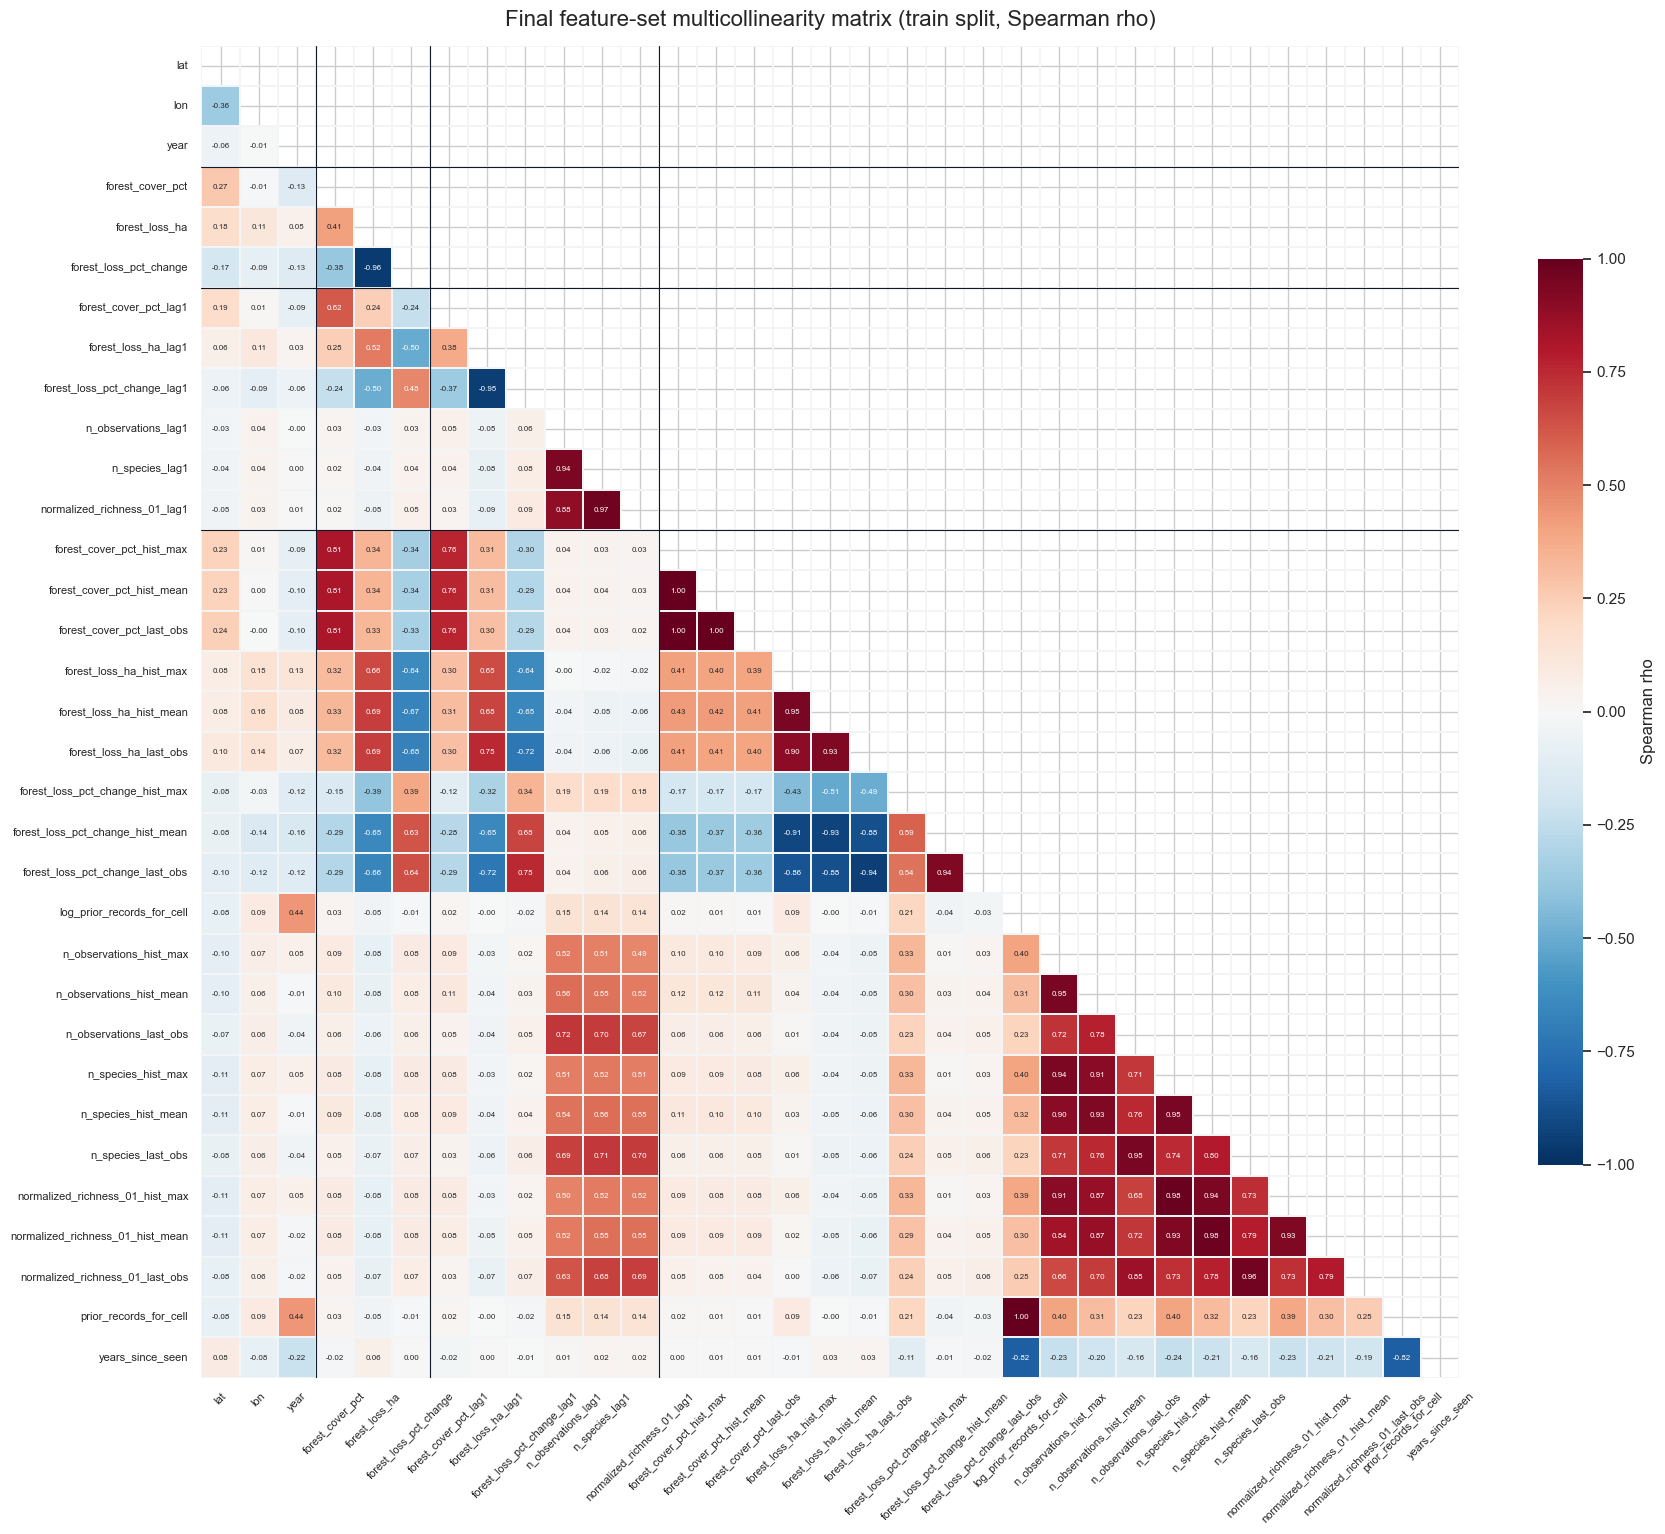

Final feature count audited: 33
Highly correlated final-feature pairs (|Spearman rho| >= 0.85): 36


,feature_a,feature_b,spearman_rho,abs_spearman_rho,block_a,block_b
0,log_prior_records_for_cell,prior_records_for_cell,1.000000,1.000000,historical grid-cell summary,historical grid-cell summary
1,forest_cover_pct_hist_max,forest_cover_pct_hist_mean,0.998810,0.998810,historical grid-cell summary,historical grid-cell summary
2,forest_cover_pct_hist_mean,forest_cover_pct_last_obs,0.996980,0.996980,historical grid-cell summary,historical grid-cell summary
3,forest_cover_pct_hist_max,forest_cover_pct_last_obs,0.995226,0.995226,historical grid-cell summary,historical grid-cell summary
4,n_species_hist_max,normalized_richness_01_hist_max,0.984591,0.984591,historical grid-cell summary,historical grid-cell summary
5,n_species_hist_mean,normalized_richness_01_hist_mean,0.977861,0.977861,historical grid-cell summary,historical grid-cell summary
6,n_species_lag1,normalized_richness_01_lag1,0.971224,0.971224,previous-year lag,previous-year lag
7,n_species_last_obs,normalized_richness_01_last_obs,0.964403,0.964403,historical grid-cell summary,historical grid-cell summary
8,forest_loss_ha,forest_loss_pct_change,-0.955247,0.955247,current forest context,current forest context
9,forest_loss_ha_lag1,forest_loss_pct_change_lag1,-0.951844,0.951844,previous-year lag,previous-year lag


,n_final_features,n_non_constant_features,n_high_corr_pairs_abs_rho_ge_0_85,max_abs_spearman_rho,n_features_vif_gt_10,interpretation
0,33,33,36,1.0,27,Correlated lag/history predictors are expected...


,feature,feature_block,r2_explained_by_other_features,vif,vif_status
0,forest_cover_pct_hist_mean,historical grid-cell summary,0.999954,21910.194856,high redundancy
1,forest_cover_pct_hist_max,historical grid-cell summary,0.999850,6658.466539,high redundancy
2,forest_cover_pct_last_obs,historical grid-cell summary,0.999811,5296.915533,high redundancy
3,n_species_last_obs,historical grid-cell summary,0.998186,551.372452,high redundancy
4,n_species_lag1,previous-year lag,0.998047,511.942912,high redundancy
5,n_observations_last_obs,historical grid-cell summary,0.997099,344.701444,high redundancy
6,n_observations_lag1,previous-year lag,0.997042,338.079441,high redundancy
7,forest_loss_ha_last_obs,historical grid-cell summary,0.995721,233.684012,high redundancy
8,normalized_richness_01_last_obs,historical grid-cell summary,0.995659,230.381626,high redundancy
9,forest_loss_pct_change_last_obs,historical grid-cell summary,0.995609,227.720468,high redundancy


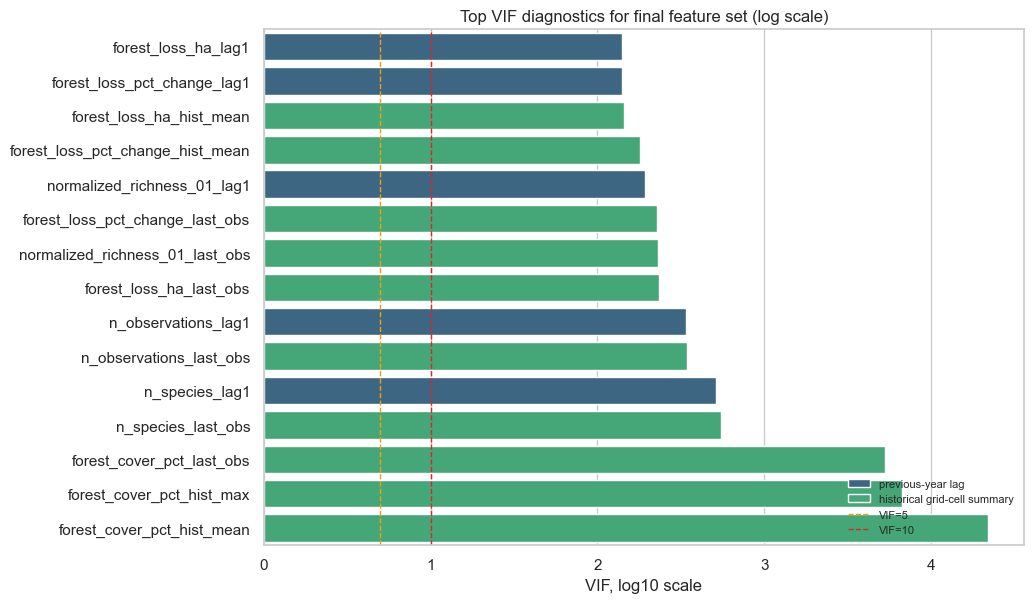

In [12]:
# Final feature-set multicollinearity audit.
# Best-practice note: do not annotate every heatmap cell for 33 features; it becomes unreadable.
# Instead, save the full matrix, show a clean heatmap, and list the strongest pairs/VIF values as tables.
feature_block_order = {
    "base spatial/temporal": 0,
    "current forest context": 1,
    "previous-year lag": 2,
    "historical grid-cell summary": 3,
    "weather context": 4,
    "other numeric": 5,
}
ordered_feature_table = (
    feature_preprocessing_audit.assign(
        block_order=lambda frame: frame["feature_block"].map(feature_block_order).fillna(99)
    )
    .sort_values(["block_order", "feature_block", "feature"])
    .reset_index(drop=True)
)
ordered_features = [feature for feature in ordered_feature_table["feature"] if feature in x_train.columns]

final_feature_corr_spearman = x_train[ordered_features].corr(method="spearman").fillna(0)
final_feature_corr_spearman.to_csv(REPORT_DIR / "final_feature_set_spearman_corr_matrix_2009_2024.csv")

high_corr_rows = []
for i, feature_a in enumerate(ordered_features):
    for feature_b in ordered_features[i + 1:]:
        rho = final_feature_corr_spearman.loc[feature_a, feature_b]
        if pd.notna(rho) and abs(rho) >= 0.85:
            high_corr_rows.append(
                {
                    "feature_a": feature_a,
                    "feature_b": feature_b,
                    "spearman_rho": float(rho),
                    "abs_spearman_rho": float(abs(rho)),
                    "block_a": ordered_feature_table.loc[ordered_feature_table["feature"] == feature_a, "feature_block"].iloc[0],
                    "block_b": ordered_feature_table.loc[ordered_feature_table["feature"] == feature_b, "feature_block"].iloc[0],
                }
            )

final_feature_high_corr_pairs = (
    pd.DataFrame(high_corr_rows)
    .sort_values("abs_spearman_rho", ascending=False)
    .reset_index(drop=True)
    if high_corr_rows
    else pd.DataFrame(columns=["feature_a", "feature_b", "spearman_rho", "abs_spearman_rho", "block_a", "block_b"])
)
final_feature_high_corr_pairs.to_csv(REPORT_DIR / "final_feature_set_high_corr_pairs_2009_2024.csv", index=False)

mask = np.triu(np.ones_like(final_feature_corr_spearman, dtype=bool))
plt.figure(figsize=(18, 15.5))
ax = sns.heatmap(
    final_feature_corr_spearman,
    mask=mask,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 5.7},
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.35,
    linecolor="#f3f4f6",
    cbar_kws={"shrink": 0.68, "label": "Spearman rho"},
)
ax.set_title("Final feature-set multicollinearity matrix (train split, Spearman rho)", fontsize=16, pad=14)
ax.set_xlabel("")
ax.set_ylabel("")
ax.tick_params(axis="x", rotation=45, labelsize=8)
ax.tick_params(axis="y", rotation=0, labelsize=8)

block_counts = ordered_feature_table.groupby("feature_block", sort=False)["feature"].count()
boundaries = block_counts.cumsum().iloc[:-1].to_numpy()
for boundary in boundaries:
    ax.axhline(boundary, color="#111827", linewidth=0.8)
    ax.axvline(boundary, color="#111827", linewidth=0.8)

plt.tight_layout()
save_figure("final_feature_set_multicollinearity_matrix_2009_2024.png")
plt.show()

print(f"Final feature count audited: {len(ordered_features)}")
print(f"Highly correlated final-feature pairs (|Spearman rho| >= 0.85): {len(final_feature_high_corr_pairs)}")
display(final_feature_high_corr_pairs.head(20))

# Variance Inflation Factor (VIF) from the same imputed train feature matrix.
# VIF is most important for linear models; here it is used as transparent evidence about redundancy.
vif_source = x_train[ordered_features].astype(float).copy()
non_constant_features = [feature for feature in ordered_features if vif_source[feature].var() > 1e-12]
vif_scaled = pd.DataFrame(
    RobustScaler().fit_transform(vif_source[non_constant_features]),
    columns=non_constant_features,
    index=vif_source.index,
)

vif_rows = []
for feature in non_constant_features:
    other_features = [candidate for candidate in non_constant_features if candidate != feature]
    if not other_features:
        r2_from_other_features = 0.0
    else:
        linear_probe = LinearRegression()
        linear_probe.fit(vif_scaled[other_features], vif_scaled[feature])
        r2_from_other_features = float(linear_probe.score(vif_scaled[other_features], vif_scaled[feature]))
    vif_value = np.inf if r2_from_other_features >= 0.999999 else 1.0 / max(1.0 - r2_from_other_features, 1e-12)
    vif_rows.append(
        {
            "feature": feature,
            "feature_block": ordered_feature_table.loc[ordered_feature_table["feature"] == feature, "feature_block"].iloc[0],
            "r2_explained_by_other_features": r2_from_other_features,
            "vif": float(vif_value) if np.isfinite(vif_value) else np.inf,
        }
    )

final_feature_vif = pd.DataFrame(vif_rows).sort_values("vif", ascending=False).reset_index(drop=True)
final_feature_vif["vif_status"] = np.select(
    [
        final_feature_vif["vif"] <= 5,
        final_feature_vif["vif"].between(5, 10, inclusive="right"),
        final_feature_vif["vif"] > 10,
    ],
    ["low/moderate", "watch", "high redundancy"],
    default="check",
)
final_feature_vif.to_csv(REPORT_DIR / "final_feature_set_vif_2009_2024.csv", index=False)

vif_summary = pd.DataFrame(
    [
        {
            "n_final_features": len(ordered_features),
            "n_non_constant_features": len(non_constant_features),
            "n_high_corr_pairs_abs_rho_ge_0_85": int(len(final_feature_high_corr_pairs)),
            "max_abs_spearman_rho": float(final_feature_high_corr_pairs["abs_spearman_rho"].max()) if len(final_feature_high_corr_pairs) else 0.0,
            "n_features_vif_gt_10": int((final_feature_vif["vif"] > 10).sum()),
            "interpretation": "Correlated lag/history predictors are expected; final tree models are robust, while linear baselines use scaling/regularization.",
        }
    ]
)
vif_summary.to_csv(REPORT_DIR / "final_feature_set_multicollinearity_summary_2009_2024.csv", index=False)

display(vif_summary)
display(final_feature_vif.head(20))

vif_plot = final_feature_vif.head(15).sort_values("vif").copy()
finite_vif_max = final_feature_vif.loc[np.isfinite(final_feature_vif["vif"]), "vif"].max()
vif_plot["vif_for_plot"] = vif_plot["vif"].replace(np.inf, finite_vif_max * 1.5).clip(lower=1.0)
vif_plot["log10_vif"] = np.log10(vif_plot["vif_for_plot"])
plt.figure(figsize=(10.5, 6.2))
sns.barplot(data=vif_plot, x="log10_vif", y="feature", hue="feature_block", dodge=False, palette="viridis")
plt.axvline(np.log10(5), color="#f59e0b", linestyle="--", linewidth=1.0, label="VIF=5")
plt.axvline(np.log10(10), color="#dc2626", linestyle="--", linewidth=1.0, label="VIF=10")
plt.title("Top VIF diagnostics for final feature set (log scale)")
plt.xlabel("VIF, log10 scale")
plt.ylabel("")
plt.legend(frameon=False, fontsize=8, loc="lower right")
plt.tight_layout()
save_figure("final_feature_set_vif_top15_2009_2024.png")
plt.show()


## 4. Feature Selection & Ablation Study

Ablation answers: **which feature blocks actually help?**

Important workflow:

1. Choose the candidate model family based on the data type: sparse tabular spatiotemporal regression → tree-based ensembles.
2. Run ablation with a fixed strong reference model so feature-block effects are isolated.
3. After choosing the best feature set, rerun multiple candidate models on that same fixed feature set.

This avoids mixing two effects: improvement from better features vs improvement from a different model.


,step,r2,mae,rmse,n_features,test_year
0,A1 current forest + raw spatial/year,0.276236,0.125507,0.185316,6,2024
1,A2 + current weather,0.271346,0.123807,0.185941,11,2024
2,A3 + previous-year biodiversity/forest lag,0.611912,0.095755,0.135700,12,2024
3,A4 + historical grid-cell summaries,0.687881,0.081705,0.121696,33,2024
4,A5 + weather history full model,0.679779,0.082377,0.123265,58,2024


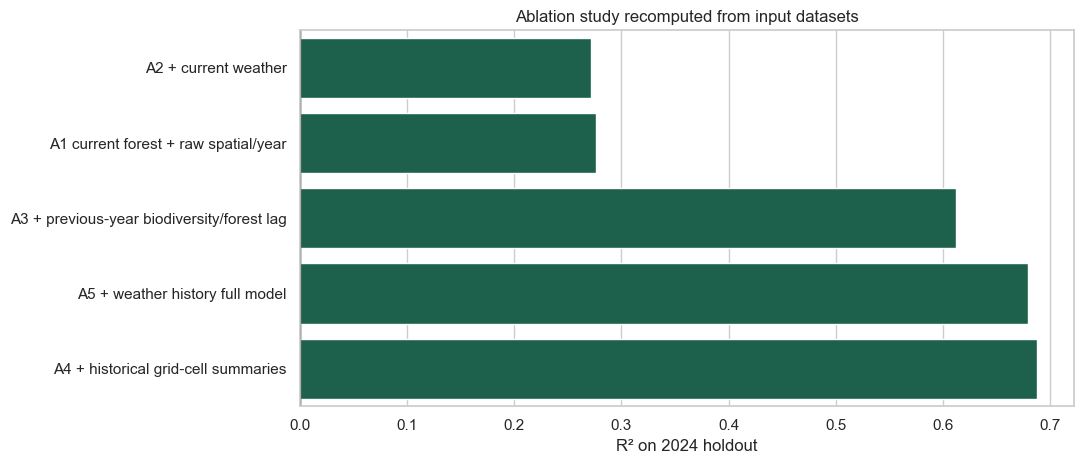

Selected feature setting from recomputed ablation:
{
  "step": "A4 + historical grid-cell summaries",
  "r2": 0.6878810074434527,
  "mae": 0.08170450309533751,
  "rmse": 0.12169579457924326,
  "n_features": 33,
  "n_train": 8119,
  "n_test": 1126,
  "test_year": 2024
}


In [13]:
# This cell intentionally recomputes ablation from the dataset loaded above.
# It does NOT read precomputed report/leaderboard CSV files, so the notebook is portable.

def score_predictions(y_true: pd.Series, y_pred: np.ndarray) -> dict[str, float]:
    y_pred = np.clip(y_pred, 0, 1)
    return {
        "r2": r2_score(y_true, y_pred),
        "mae": mean_absolute_error(y_true, y_pred),
        "rmse": np.sqrt(mean_squared_error(y_true, y_pred)),
    }


def fit_reference_xgb(frame: pd.DataFrame, features: list[str], label: str) -> dict[str, float | int | str]:
    train_part = frame[frame["year"] < TEST_YEAR].copy()
    test_part = frame[frame["year"] == TEST_YEAR].copy()
    if not features:
        pred_test = np.full(len(test_part), train_part[TARGET].mean())
    else:
        train_medians = train_part[features].median().fillna(0)
        x_train_part = train_part[features].fillna(train_medians)
        y_train_part = train_part[TARGET]
        x_test_part = test_part[features].fillna(train_medians)
        model = XGBRegressor(
            objective="reg:logistic",
            n_estimators=450,
            max_depth=4,
            learning_rate=0.03,
            subsample=0.85,
            colsample_bytree=0.9,
            reg_lambda=8,
            min_child_weight=2,
            random_state=RANDOM_STATE,
            n_jobs=4,
            tree_method="hist",
        )
        model.fit(x_train_part, y_train_part)
        pred_test = model.predict(x_test_part)
    metrics = score_predictions(test_part[TARGET], pred_test)
    return {
        "step": label,
        **metrics,
        "n_features": len(features),
        "n_train": len(train_part),
        "n_test": len(test_part),
        "test_year": TEST_YEAR,
    }

base_features = [column for column in ["year", "lat", "lon", "forest_cover_pct", "forest_loss_ha", "forest_loss_pct_change"] if column in final_frame.columns]
lag_features = [column for column in feature_cols if column.endswith("_lag1")]
history_features = [column for column in feature_cols if any(token in column for token in ["_hist_", "_last_obs", "prior_records", "years_since_seen"])]

weather_frame = build_modeling_frame(
    include_weather=True,
    include_xy_features=False,
    include_year_features=False,
)
weather_feature_cols = select_forecast_features(weather_frame)
current_weather_features = [column for column in ["avg_temp", "total_rainfall_mm", "n_dry_days", "n_hot_days", "temp_anomaly"] if column in weather_feature_cols]

ablation_specs = [
    (final_frame, base_features, "A1 current forest + raw spatial/year"),
    (weather_frame, sorted(set(base_features + current_weather_features)), "A2 + current weather"),
    (final_frame, sorted(set(base_features + lag_features)), "A3 + previous-year biodiversity/forest lag"),
    (final_frame, feature_cols, "A4 + historical grid-cell summaries"),
    (weather_frame, weather_feature_cols, "A5 + weather history full model"),
]

ablation_rows = [fit_reference_xgb(frame, features, label) for frame, features, label in ablation_specs]
ablation = pd.DataFrame(ablation_rows)
ablation_clean = ablation[ablation["n_features"].ge(0)].copy()
ablation_display = ablation_clean[["step", "r2", "mae", "rmse", "n_features", "test_year"]].copy()
ablation.to_csv(REPORT_DIR / "final_ablation_2009_2024.csv", index=False)

display(ablation_display)

plt.figure(figsize=(11, 4.8))
plot_ablation = ablation_clean.sort_values("r2", ascending=True)
colors = ["#126b50" for _ in plot_ablation["step"]]
sns.barplot(data=plot_ablation, x="r2", y="step", palette=colors, hue="step", legend=False)
plt.axvline(0, color="black", linewidth=1)
plt.title("Ablation study recomputed from input datasets")
plt.xlabel("R² on 2024 holdout")
plt.ylabel("")
plt.tight_layout()
save_figure("final_pipeline_ablation_recomputed_2009_2024.png")
plt.show()

best_ablation_row = ablation_clean.sort_values("r2", ascending=False).iloc[0].to_dict()
print("Selected feature setting from recomputed ablation:")
print(json.dumps(best_ablation_row, indent=2))


In [14]:
print("No external leaderboard/report CSV is read here.")
print("The full model-family leaderboard is generated from scratch in Section 5 using the same final feature set.")

ablation_note = pd.DataFrame(
    [
        {
            "artifact": "final_ablation_2009_2024.csv",
            "role": "generated output, not required input",
            "source": "computed in this notebook from GBIF + forest + weather CSVs",
        },
        {
            "artifact": "final_full_pipeline_model_leaderboard_2009_2024.csv",
            "role": "generated output, not required input",
            "source": "computed later in Section 5 from the same input datasets",
        },
    ]
)
display(ablation_note)


No external leaderboard/report CSV is read here.
The full model-family leaderboard is generated from scratch in Section 5 using the same final feature set.


,artifact,role,source
0,final_ablation_2009_2024.csv,"generated output, not required input",computed in this notebook from GBIF + forest +...
1,final_full_pipeline_model_leaderboard_2009_202...,"generated output, not required input",computed later in Section 5 from the same inpu...


## 5. Modelling + Hyperparameter Tuning

This section trains a **post-ablation model leaderboard** on the same final feature set, now including simple linear baselines.

Candidate model groups:

- Linear models: Linear Regression, Ridge, ElasticNet
- Bagging tree ensembles: Random Forest, ExtraTrees
- Boosted trees: HistGradientBoosting and XGBoost logistic

Tuning protocol:

- Hyperparameters are selected using a temporal validation split: **train 2009–2022, validate 2023**.
- The final selected configuration for each model family is retrained on **2009–2023**.
- The final untouched temporal test set remains **2024**.
- All models use the same selected final feature columns.
- Current-year `n_species`, `n_observations`, and target-derived diversity columns are excluded.

This keeps model selection separate from final test evaluation and gives a fair benchmark against linear baselines.

The leaderboard reports R² gaps versus the best linear baseline, keeping the method-family comparison focused on the final XGBoost logistic model.


Tuning split: train=7,169 rows (2009–2022), validation=950 rows (2023)


Best validation result per model family:


,model,candidate_id,params,valid_r2,valid_mae,valid_rmse
0,xgboost_logistic,0,"{""colsample_bytree"": 0.9, ""learning_rate"": 0.0...",0.630343,0.084465,0.127664
1,elastic_net,7,"{""alpha"": 0.005, ""l1_ratio"": 0.5}",0.612979,0.085714,0.130627
2,ridge,1,"{""alpha"": 1.0}",0.606683,0.084071,0.131686
3,linear_regression,0,{},0.605929,0.084237,0.131812
4,hist_gradient_boosting,2,"{""l2_regularization"": 0.1, ""learning_rate"": 0....",0.583899,0.088629,0.135446
5,extra_trees,0,"{""max_depth"": 18, ""max_features"": 0.7, ""min_sa...",0.579854,0.088139,0.136103
6,random_forest,1,"{""max_depth"": 18, ""max_features"": ""sqrt"", ""min...",0.573926,0.088220,0.137060


Final model leaderboard with honest R² gaps:


,model,model_family_group,selected_by_valid_r2,r2,mae,rmse,delta_r2_vs_best_linear,valid_to_test_r2_shift,n_features
0,xgboost_logistic,30 boosted trees,0.630343,0.689183,0.081608,0.121442,0.028205,0.058841,33
1,hist_gradient_boosting,30 boosted trees,0.583899,0.686290,0.081338,0.122006,0.025311,0.102391,33
2,extra_trees,20 bagging trees,0.579854,0.683478,0.081446,0.122551,0.022500,0.103624,33
3,random_forest,20 bagging trees,0.573926,0.666749,0.083737,0.125748,0.005770,0.092823,33
4,ridge,10 linear baseline,0.606683,0.660978,0.081476,0.126832,0.000000,0.054295,33
5,linear_regression,10 linear baseline,0.605929,0.660695,0.081471,0.126885,-0.000284,0.054765,33
6,elastic_net,10 linear baseline,0.612979,0.648772,0.084932,0.129095,-0.012207,0.035792,33


Best model per family group:


,model_family_group,model,selected_by_valid_r2,r2,mae,rmse,delta_r2_vs_best_linear
2,30 boosted trees,xgboost_logistic,0.630343,0.689183,0.081608,0.121442,0.028205
1,20 bagging trees,extra_trees,0.579854,0.683478,0.081446,0.122551,0.022500
0,10 linear baseline,ridge,0.606683,0.660978,0.081476,0.126832,0.000000


Selected final model by validation 2023: xgboost_logistic


,validation,selection_policy,selected_model,selected_params,r2,mae,rmse,n_train,n_test,n_features
0,holdout_2024,"best validation R2 on 2023, then retrain 2009-...",xgboost_logistic,"{""colsample_bytree"": 0.9, ""learning_rate"": 0.0...",0.689183,0.081608,0.121442,8119,1126,33


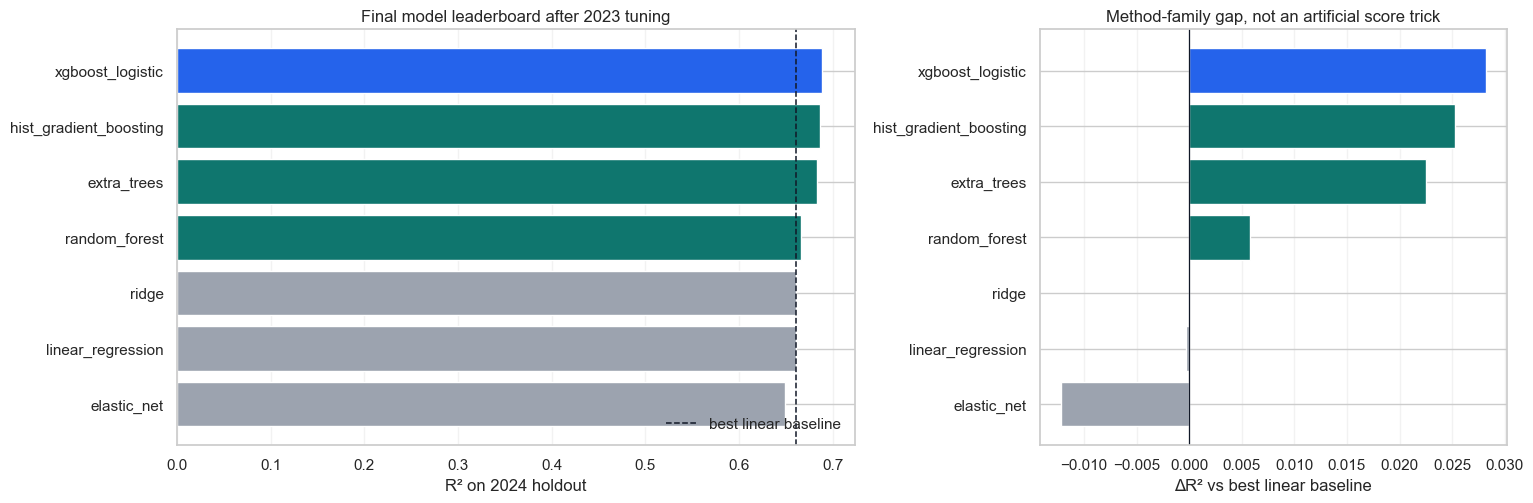

,grid_id,lat,lon,year,normalized_richness_01,n_species,n_observations,prediction,residual_actual_minus_pred
0,VN_10.03_103.94,10.03,103.94,2024,0.067660,2,2,0.091803,-0.024143
10,VN_10.03_104.03,10.03,104.03,2024,0.474961,56,79,0.306353,0.168609
13,VN_10.03_105.11,10.03,105.11,2024,0.201072,15,15,0.159333,0.041738
16,VN_10.03_105.28,10.03,105.28,2024,0.053619,1,1,0.084509,-0.030890
19,VN_10.03_105.64,10.03,105.64,2024,0.067660,2,2,0.114744,-0.047084


In [15]:
def make_model(model_name: str, params: dict | None = None) -> object | None:
    """Build a fresh model from a model family name and small hyperparameter dict."""
    params = params or {}
    if model_name == "linear_regression":
        return Pipeline([("scale", RobustScaler()), ("model", LinearRegression())])
    if model_name == "ridge":
        return Pipeline([("scale", RobustScaler()), ("model", Ridge(alpha=params.get("alpha", 1.0)))])
    if model_name == "elastic_net":
        return Pipeline(
            [
                ("scale", RobustScaler()),
                (
                    "model",
                    ElasticNet(
                        alpha=params.get("alpha", 0.001),
                        l1_ratio=params.get("l1_ratio", 0.2),
                        max_iter=20_000,
                        random_state=RANDOM_STATE,
                    ),
                ),
            ]
        )
    if model_name == "random_forest":
        return RandomForestRegressor(
            n_estimators=params.get("n_estimators", 350),
            max_depth=params.get("max_depth", 18),
            min_samples_leaf=params.get("min_samples_leaf", 5),
            max_features=params.get("max_features", "sqrt"),
            random_state=RANDOM_STATE,
            n_jobs=4,
        )
    if model_name == "extra_trees":
        return ExtraTreesRegressor(
            n_estimators=params.get("n_estimators", 500),
            max_depth=params.get("max_depth", 22),
            min_samples_leaf=params.get("min_samples_leaf", 3),
            max_features=params.get("max_features", 0.7),
            random_state=RANDOM_STATE,
            n_jobs=4,
        )
    if model_name == "hist_gradient_boosting":
        return HistGradientBoostingRegressor(
            loss="squared_error",
            learning_rate=params.get("learning_rate", 0.035),
            max_iter=params.get("max_iter", 450),
            max_leaf_nodes=params.get("max_leaf_nodes", 31),
            l2_regularization=params.get("l2_regularization", 0.05),
            random_state=RANDOM_STATE,
        )
    if model_name == "xgboost_logistic":
        return Pipeline(
            [
                ("scale", RobustScaler()),
                (
                    "model",
                    XGBRegressor(
                        objective="reg:logistic",
                        n_estimators=params.get("n_estimators", 700),
                        max_depth=params.get("max_depth", 3),
                        learning_rate=params.get("learning_rate", 0.025),
                        subsample=params.get("subsample", 0.85),
                        colsample_bytree=params.get("colsample_bytree", 0.9),
                        reg_lambda=params.get("reg_lambda", 5),
                        min_child_weight=params.get("min_child_weight", 1),
                        random_state=RANDOM_STATE,
                        n_jobs=4,
                        tree_method="hist",
                    ),
                ),
            ]
        )
    raise ValueError(f"Unknown model: {model_name}")


# Small, reproducible tuning grid. It is intentionally compact so the full notebook stays runnable.
param_grid: dict[str, list[dict]] = {
    "linear_regression": [{}],
    "ridge": [{"alpha": alpha} for alpha in [0.1, 1.0, 10.0, 100.0]],
    "elastic_net": [
        {"alpha": alpha, "l1_ratio": l1_ratio}
        for alpha in [0.0005, 0.001, 0.005]
        for l1_ratio in [0.1, 0.5, 0.9]
    ],
    "random_forest": [
        {"n_estimators": 300, "max_depth": 14, "min_samples_leaf": 5, "max_features": "sqrt"},
        {"n_estimators": 350, "max_depth": 18, "min_samples_leaf": 5, "max_features": "sqrt"},
        {"n_estimators": 350, "max_depth": 18, "min_samples_leaf": 3, "max_features": 0.7},
    ],
    "extra_trees": [
        {"n_estimators": 450, "max_depth": 18, "min_samples_leaf": 3, "max_features": 0.7},
        {"n_estimators": 500, "max_depth": 22, "min_samples_leaf": 3, "max_features": 0.7},
        {"n_estimators": 500, "max_depth": 24, "min_samples_leaf": 2, "max_features": 0.8},
    ],
    "hist_gradient_boosting": [
        {"learning_rate": 0.03, "max_iter": 450, "max_leaf_nodes": 31, "l2_regularization": 0.05},
        {"learning_rate": 0.035, "max_iter": 450, "max_leaf_nodes": 31, "l2_regularization": 0.05},
        {"learning_rate": 0.025, "max_iter": 600, "max_leaf_nodes": 31, "l2_regularization": 0.1},
        {"learning_rate": 0.035, "max_iter": 450, "max_leaf_nodes": 63, "l2_regularization": 0.1},
    ],
    "xgboost_logistic": [
        {"n_estimators": 600, "max_depth": 3, "learning_rate": 0.03, "reg_lambda": 5, "subsample": 0.85, "colsample_bytree": 0.9},
        {"n_estimators": 700, "max_depth": 3, "learning_rate": 0.025, "reg_lambda": 5, "subsample": 0.85, "colsample_bytree": 0.9},
        {"n_estimators": 650, "max_depth": 4, "learning_rate": 0.025, "reg_lambda": 8, "subsample": 0.85, "colsample_bytree": 0.9, "min_child_weight": 2},
    ],
}


def evaluate_predictions(y_true: pd.Series, pred: np.ndarray) -> dict[str, float]:
    pred = np.clip(pred, 0, 1)
    return {
        "r2": r2_score(y_true, pred),
        "mae": mean_absolute_error(y_true, pred),
        "rmse": np.sqrt(mean_squared_error(y_true, pred)),
    }


# Validation split for tuning: never tune on 2024.
tune_train = final_frame[final_frame["year"] < 2023].copy()
validation = final_frame[final_frame["year"] == 2023].copy()
tune_medians = tune_train[feature_cols].median().fillna(0)
x_tune_train = tune_train[feature_cols].fillna(tune_medians)
y_tune_train = tune_train[TARGET]
x_valid = validation[feature_cols].fillna(tune_medians)
y_valid = validation[TARGET]

print(f"Tuning split: train={len(tune_train):,} rows (2009–2022), validation={len(validation):,} rows (2023)")

tuning_rows = []
for model_name, grid in param_grid.items():
    for candidate_id, params in enumerate(grid):
        model = make_model(model_name, params)
        if model is None:
            valid_pred = np.full(len(y_valid), y_tune_train.mean())
        else:
            model.fit(x_tune_train, y_tune_train)
            valid_pred = model.predict(x_valid)
        valid_metrics = evaluate_predictions(y_valid, valid_pred)
        tuning_rows.append(
            {
                "model": model_name,
                "candidate_id": candidate_id,
                "params": json.dumps(params, sort_keys=True),
                "validation_year": 2023,
                **{f"valid_{key}": value for key, value in valid_metrics.items()},
            }
        )

hyperparam_results = pd.DataFrame(tuning_rows).sort_values(["model", "valid_r2"], ascending=[True, False]).reset_index(drop=True)
hyperparam_results.to_csv(REPORT_DIR / "final_full_pipeline_hyperparam_tuning_2023.csv", index=False)

best_params_by_model = (
    hyperparam_results.sort_values("valid_r2", ascending=False)
    .groupby("model", as_index=False)
    .first()[["model", "candidate_id", "params", "valid_r2", "valid_mae", "valid_rmse"]]
    .sort_values("valid_r2", ascending=False)
    .reset_index(drop=True)
)
print("Best validation result per model family:")
display(best_params_by_model)

# Final leaderboard: retrain each model-family winner on 2009–2023, then evaluate on untouched 2024.
fitted_models: dict[str, object] = {}
model_predictions: dict[str, np.ndarray] = {}
leaderboard_rows = []

for row in best_params_by_model.itertuples(index=False):
    model_name = str(row.model)
    params = json.loads(row.params)
    model = make_model(model_name, params)
    if model is None:
        test_pred = np.full(len(y_test), y_train.mean())
    else:
        model.fit(x_train, y_train)
        fitted_models[model_name] = model
        test_pred = model.predict(x_test)

    test_pred = np.clip(test_pred, 0, 1)
    model_predictions[model_name] = test_pred
    test_metrics = evaluate_predictions(y_test, test_pred)
    leaderboard_rows.append(
        {
            "model": model_name,
            "selected_by_valid_r2": row.valid_r2,
            "selected_params": row.params,
            **test_metrics,
            "n_train": len(train),
            "n_test": len(test),
            "n_features": len(feature_cols),
            "feature_policy": "same final post-ablation feature set; no current-year n_species/n_observations/target columns",
        }
    )

model_leaderboard = pd.DataFrame(leaderboard_rows).sort_values("r2", ascending=False).reset_index(drop=True)

family_map = {
    "linear_regression": "10 linear baseline",
    "ridge": "10 linear baseline",
    "elastic_net": "10 linear baseline",
    "random_forest": "20 bagging trees",
    "extra_trees": "20 bagging trees",
    "hist_gradient_boosting": "30 boosted trees",
    "xgboost_logistic": "30 boosted trees",
}
model_leaderboard["model_family_group"] = model_leaderboard["model"].map(family_map).fillna("99 other")
linear_models = {"linear_regression", "ridge", "elastic_net"}
best_linear_r2 = float(model_leaderboard.loc[model_leaderboard["model"].isin(linear_models), "r2"].max())
model_leaderboard["delta_r2_vs_best_linear"] = model_leaderboard["r2"] - best_linear_r2
model_leaderboard["valid_to_test_r2_shift"] = model_leaderboard["r2"] - model_leaderboard["selected_by_valid_r2"]

family_best = (
    model_leaderboard.sort_values("r2", ascending=False)
    .groupby("model_family_group", as_index=False)
    .first()[["model_family_group", "model", "selected_by_valid_r2", "r2", "mae", "rmse", "delta_r2_vs_best_linear"]]
    .sort_values("r2", ascending=False)
)

model_leaderboard.to_csv(REPORT_DIR / "final_full_pipeline_model_leaderboard_2009_2024.csv", index=False)
model_leaderboard.to_csv(REPORT_DIR / "final_full_pipeline_model_leaderboard_with_gaps_2009_2024.csv", index=False)
family_best.to_csv(REPORT_DIR / "final_full_pipeline_family_best_with_gaps_2009_2024.csv", index=False)

leaderboard_display_cols = [
    "model",
    "model_family_group",
    "selected_by_valid_r2",
    "r2",
    "mae",
    "rmse",
    "delta_r2_vs_best_linear",
    "valid_to_test_r2_shift",
    "n_features",
]
print("Final model leaderboard with honest R² gaps:")
display(model_leaderboard[leaderboard_display_cols])
print("Best model per family group:")
display(family_best)

# Selection policy for final model: choose by validation R², not by 2024 test R².
selected_by_validation = best_params_by_model.iloc[0]
final_model_name = str(selected_by_validation["model"])
final_model = fitted_models.get(final_model_name)
pred = model_predictions[final_model_name]
metrics = {
    "validation": f"holdout_{TEST_YEAR}",
    "selection_policy": "best validation R2 on 2023, then retrain 2009-2023 and test once on 2024",
    "selected_model": final_model_name,
    "selected_params": selected_by_validation["params"],
    "r2": r2_score(y_test, pred),
    "mae": mean_absolute_error(y_test, pred),
    "rmse": np.sqrt(mean_squared_error(y_test, pred)),
    "n_train": len(train),
    "n_test": len(test),
    "n_features": len(feature_cols),
}
print("Selected final model by validation 2023:", final_model_name)
display(pd.DataFrame([metrics]))

predictions = test[["grid_id", "lat", "lon", "year", TARGET, "n_species", "n_observations"]].copy()
predictions["prediction"] = pred
predictions["residual_actual_minus_pred"] = predictions[TARGET] - predictions["prediction"]

plot_df = model_leaderboard.sort_values("r2", ascending=True).copy()
colors = [
    "#2563eb" if name.startswith("xgboost") else "#9ca3af" if name in {"linear_regression", "ridge", "elastic_net"} else "#0f766e"
    for name in plot_df["model"]
]
fig, axes = plt.subplots(1, 2, figsize=(15.5, 5.2), gridspec_kw={"width_ratios": [1.45, 1]})
axes[0].barh(plot_df["model"], plot_df["r2"], color=colors)
axes[0].axvline(best_linear_r2, color="#111827", linestyle="--", linewidth=1.1, label="best linear baseline")
axes[0].set_xlabel("R² on 2024 holdout")
axes[0].set_title("Final model leaderboard after 2023 tuning")
axes[0].legend(frameon=False, loc="lower right")

axes[1].barh(plot_df["model"], plot_df["delta_r2_vs_best_linear"], color=colors)
axes[1].axvline(0, color="#111827", linewidth=0.9)
axes[1].set_xlabel("ΔR² vs best linear baseline")
axes[1].set_title("Method-family gap, not an artificial score trick")
for ax in axes:
    ax.grid(axis="x", alpha=0.25)
plt.tight_layout()
save_figure("final_pipeline_model_leaderboard_with_gaps.png")
plt.show()

display(predictions.head())


## 6. Evaluation

The final result is best interpreted as a **relative richness forecast**, not a species count forecast. R² around 0.69 is strong for this noisy citizen-science, spatiotemporal setting, especially under the no-current-year-effort leakage rule.

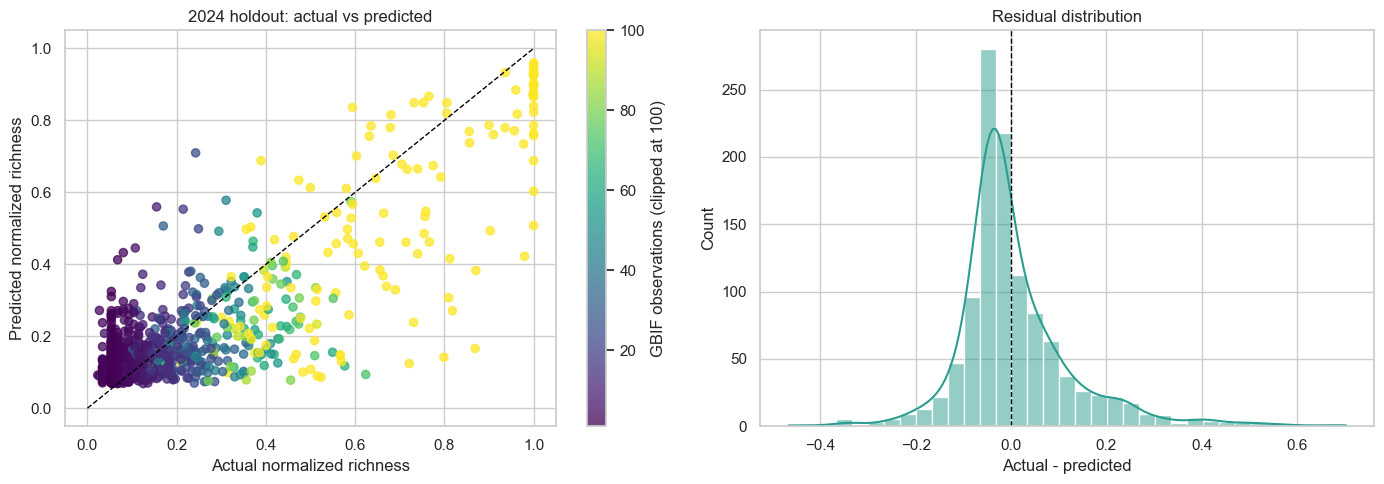

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

scatter = axes[0].scatter(
    predictions[TARGET],
    predictions["prediction"],
    c=np.clip(predictions["n_observations"], 0, 100),
    cmap="viridis",
    alpha=0.75,
    s=35,
)
axes[0].plot([0, 1], [0, 1], "--", color="black", linewidth=1)
axes[0].set_title("2024 holdout: actual vs predicted")
axes[0].set_xlabel("Actual normalized richness")
axes[0].set_ylabel("Predicted normalized richness")
plt.colorbar(scatter, ax=axes[0], label="GBIF observations (clipped at 100)")

sns.histplot(predictions["residual_actual_minus_pred"], bins=35, kde=True, color="#2a9d8f", ax=axes[1])
axes[1].axvline(0, color="black", linestyle="--", linewidth=1)
axes[1].set_title("Residual distribution")
axes[1].set_xlabel("Actual - predicted")
plt.tight_layout()
plt.show()

In [17]:
def region_band(lat: float) -> str:
    if lat < 13:
        return "South"
    if lat < 18:
        return "Central"
    return "North"

predictions["region_band"] = predictions["lat"].map(region_band)
region_metrics = []
for region, group in predictions.groupby("region_band"):
    region_metrics.append({
        "region_band": region,
        "n": len(group),
        "r2": r2_score(group[TARGET], group["prediction"]),
        "mae": mean_absolute_error(group[TARGET], group["prediction"]),
        "bias_actual_minus_pred": (group[TARGET] - group["prediction"]).mean(),
    })
region_metrics = pd.DataFrame(region_metrics).sort_values("region_band")
region_metrics.to_csv(REPORT_DIR / "final_region_error_2009_2024.csv", index=False)
display(region_metrics)

# Grid-based robustness check is recomputed here, not loaded from any report file.
# It tests whether the selected modelling approach transfers to held-out grid cells.
n_splits = min(5, train["grid_id"].nunique())
group_kfold = GroupKFold(n_splits=n_splits)
group_kfold_scores = cross_val_score(
    final_model,
    x_train,
    y_train,
    groups=train["grid_id"],
    cv=group_kfold,
    scoring="r2",
    n_jobs=1,
)
group_kfold_summary = {
    "group_kfold_r2_mean": float(group_kfold_scores.mean()),
    "group_kfold_r2_std": float(group_kfold_scores.std()),
    "n_splits": int(n_splits),
}
print(
    f"GroupKFold by grid_id R² recomputed in notebook: "
    f"{group_kfold_summary['group_kfold_r2_mean']:.3f} ± {group_kfold_summary['group_kfold_r2_std']:.3f}"
)


,region_band,n,r2,mae,bias_actual_minus_pred
0,Central,255,0.636874,0.080805,0.004849
1,North,378,0.718425,0.077320,0.006446
2,South,493,0.685210,0.085311,0.006597


GroupKFold by grid_id R² recomputed in notebook: 0.578 ± 0.041


## 7. Interpretation

Top features show that the model is not guessing randomly: it relies heavily on historical richness, historical observation effort, persistence of species signals in the same grid, and forest context.

,feature,importance
0,n_species_hist_mean,0.201423
1,n_species_hist_max,0.182556
2,n_observations_hist_max,0.167719
3,normalized_richness_01_hist_max,0.076655
4,n_species_lag1,0.064521
5,n_observations_lag1,0.045098
6,normalized_richness_01_hist_mean,0.037996
7,normalized_richness_01_lag1,0.032381
8,years_since_seen,0.026425
9,n_observations_hist_mean,0.024614


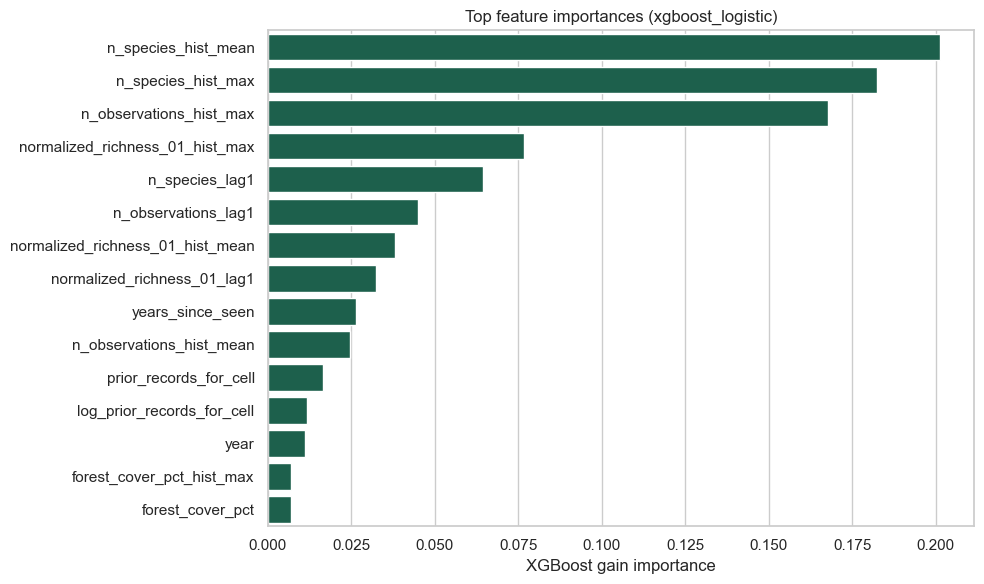

In [18]:
model_for_importance = final_model.named_steps["model"] if isinstance(final_model, Pipeline) else final_model
importance = (
    pd.DataFrame({"feature": feature_cols, "importance": model_for_importance.feature_importances_})
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)
importance.to_csv(REPORT_DIR / "final_full_pipeline_feature_importance.csv", index=False)
display(importance.head(20))

plt.figure(figsize=(10, 6))
sns.barplot(data=importance.head(15), x="importance", y="feature", color="#126b50")
plt.title(f"Top feature importances ({final_model_name})")
plt.xlabel("XGBoost gain importance")
plt.ylabel("")
plt.tight_layout()
plt.show()


## 8. Final Takeaways + Demo Connection

**Main result:** the final honest-forecast model reaches about **R² ≈ 0.69** on the 2024 temporal holdout while avoiding current-year biodiversity/effort leakage.

**Why the final feature set is defensible:**

- Current forest + spatial/year features provide useful signal, but are not enough alone.
- Current forest + spatial/year features help, but are not enough.
- Lag/history features produce the major performance jump.
- Weather history was tested, but did not improve the final model enough to justify extra missingness/complexity.
- Evaluation includes temporal holdout and grid-based cross-validation.

**Web demo:** the React/FastAPI demo uses the same final modelling idea: 2024 predicted richness map, selected-grid explanation, and forest-only scenario simulation.

In [19]:
final_summary = {
    "target": TARGET,
    "test_year": TEST_YEAR,
    "selected_model": final_model_name,
    "selection_policy": metrics["selection_policy"],
    "selected_params": metrics["selected_params"],
    "hyperparam_tuning_output": str(REPORT_DIR / "final_full_pipeline_hyperparam_tuning_2023.csv"),
    "leaderboard_output": str(REPORT_DIR / "final_full_pipeline_model_leaderboard_2009_2024.csv"),
    "leaderboard_gap_output": str(REPORT_DIR / "final_full_pipeline_model_leaderboard_with_gaps_2009_2024.csv"),
    "multicollinearity_matrix_output": str(REPORT_DIR / "final_feature_set_spearman_corr_matrix_2009_2024.csv"),
    "multicollinearity_vif_output": str(REPORT_DIR / "final_feature_set_vif_2009_2024.csv"),
    "multicollinearity_summary_output": str(REPORT_DIR / "final_feature_set_multicollinearity_summary_2009_2024.csv"),
    "group_kfold_r2_mean": group_kfold_summary["group_kfold_r2_mean"],
    "group_kfold_r2_std": group_kfold_summary["group_kfold_r2_std"],
    "feature_policy": "honest forecast: excludes current-year n_species, n_observations, and target-derived diversity columns",
    "n_train": len(train),
    "n_test": len(test),
    "n_features": len(feature_cols),
    "r2": float(metrics["r2"]),
    "mae": float(metrics["mae"]),
    "rmse": float(metrics["rmse"]),
    "web_demo": str(PROJECT_ROOT / "web-demo"),
}
print(json.dumps(final_summary, indent=2))


{
  "target": "normalized_richness_01",
  "test_year": 2024,
  "selected_model": "xgboost_logistic",
  "selection_policy": "best validation R2 on 2023, then retrain 2009-2023 and test once on 2024",
  "selected_params": "{\"colsample_bytree\": 0.9, \"learning_rate\": 0.03, \"max_depth\": 3, \"n_estimators\": 600, \"reg_lambda\": 5, \"subsample\": 0.85}",
  "hyperparam_tuning_output": "/Users/longle/CS313/biodiversity/notebook_worktree/reports/final_full_pipeline_hyperparam_tuning_2023.csv",
  "leaderboard_output": "/Users/longle/CS313/biodiversity/notebook_worktree/reports/final_full_pipeline_model_leaderboard_2009_2024.csv",
  "leaderboard_gap_output": "/Users/longle/CS313/biodiversity/notebook_worktree/reports/final_full_pipeline_model_leaderboard_with_gaps_2009_2024.csv",
  "multicollinearity_matrix_output": "/Users/longle/CS313/biodiversity/notebook_worktree/reports/final_feature_set_spearman_corr_matrix_2009_2024.csv",
  "multicollinearity_vif_output": "/Users/longle/CS313/biodive